# 10A — การวิเคราะห์พื้นที่รับอิทธิพลของพายุและลูกเห็บด้วย GIS
## GIS Exposure and Administrative Analysis

**Track A — Applied Radar–GIS / Environmental Research**

กรณีศึกษา:

- Omkoi S-band weather radar
- Observed-hail event: 18 March 2023
- Severe-storm products: Notebook 07
- Hail products: Notebook 08
- Integrated lifecycle: Notebook 09A
- GIS boundaries: Thailand ADM1 / ADM2 from the course canonical GeoPackage

---

## เป้าหมายของบท

Notebook 09A วิเคราะห์ว่า storm และ hail-related radar metrics เปลี่ยนอย่างไรตามเวลา

Notebook 10A เปลี่ยนมุมมองจาก:

```text
storm-centric analysis
```

เป็น:

```text
administrative exposure analysis
```

workflow หลัก:

```text
Peak radar hazard products
        +
ADM1 / ADM2 boundaries
        ↓
CRS harmonization
        ↓
Raster–polygon zonal statistics
        ↓
Administrative exposure tables
        ↓
Storm-core track intersection
        ↓
GIS maps and GeoPackage
```

> **Exposure ≠ impact**
>
> การที่อำเภอหนึ่งมี MESH, ET50 หรือ VIL สูง ไม่ได้หมายความว่ามีความเสียหายหรือมีลูกเห็บถึงพื้นในทุกพื้นที่ของอำเภอนั้น

# ผลลัพธ์การเรียนรู้

เมื่อจบ Notebook 10A ผู้เรียนควรสามารถ:

1. อ่าน administrative boundaries จาก GeoPackage
2. ตรวจ CRS ของ vector และ raster
3. reproject polygons ให้ตรงกับ radar raster
4. อธิบาย pixel-center และ `all_touched`
5. คำนวณ zonal statistics จาก radar-derived raster
6. แยก valid radar coverage ออกจาก non-exposure
7. คำนวณ mean, median, P90, P95 และ maximum
8. คำนวณ threshold exceedance area
9. สร้าง administrative ranking อย่างมี coverage filter
10. เปรียบเทียบ ADM1 และ ADM2
11. สร้าง storm-core centroid track จาก Notebook 07
12. แปลง radar-centered x/y เป็น geographic coordinates
13. วิเคราะห์ว่า core track ผ่านเขตการปกครองใด
14. แยก storm-core track exposure ออกจาก MESH footprint exposure
15. ทำ sensitivity ระหว่าง pixel-center กับ `all_touched=True`
16. สร้าง publication-quality GIS maps
17. export CSV และ GeoPackage
18. รักษา provenance ของ MESH thermal input
19. อธิบายว่าทำไม GIS overlay ไม่ใช่ physical validation
20. เตรียม outputs สำหรับ Notebook 11A research mini-project

**CORE** — ปริญญาตรี  
**ADVANCED** — ปริญญาโท  
**RESEARCH NOTE** — ประเด็นสำหรับ manuscript

# 1. Exposure ใน Notebook นี้หมายถึงอะไร

คำว่า **exposure** ในบทนี้หมายถึง:

> เขตการปกครองที่ซ้อนทับกับ radar-derived storm/hail signatures ภายใต้เงื่อนไขที่กำหนด

ตัวอย่าง:

```text
ADM2 polygon
+
MESH ≥ 40 mm pixels
        ↓
area of radar-derived MESH ≥ 40 mm
within that district
```

ไม่ได้หมายถึง:

```text
verified hail damage
population affected
building damage
crop loss
```

สิ่งเหล่านี้ต้องมี impact dataset เพิ่มเติม

# 2. Raster–polygon zonal statistics

สำหรับ polygon หนึ่ง เราจะสรุปค่าจาก raster cells ที่อยู่ภายใน polygon

ตัวอย่าง:

$$
\bar{x}
=
\frac{1}{N}
\sum_{i=1}^{N} x_i
$$

และ percentile:

```text
median
P90
P95
maximum
```

สำหรับพื้นที่ที่ผ่าน threshold:

$$
A_T
=
N_T
\Delta x
\Delta y
$$

โดย:

- $N_T$ = จำนวน pixels ที่ผ่าน threshold
- $\Delta x\Delta y$ = พื้นที่ pixel

# 3. Pixel center vs all_touched

Rasterization มีสองแนวทางสำคัญ

### Pixel-center rule

```text
all_touched = False
```

นับ pixel หากศูนย์กลาง pixel อยู่ใน polygon

ข้อดี:

- conservative
- reproducible
- ลดการขยาย footprint ตามขอบ polygon

### all_touched rule

```text
all_touched = True
```

นับทุก pixel ที่สัมผัส polygon

ข้อดี:

- เหมาะกับบางงาน exposure screening

ข้อจำกัด:

- อาจเพิ่มพื้นที่โดยเฉพาะ polygon เล็กหรือขอบเขตซับซ้อน

Notebook ใช้ pixel-center เป็น primary method และใช้ `all_touched=True` เป็น sensitivity สำหรับ MESH

# 4. Radar thresholds ในบทนี้

Thresholds ถูกใช้เป็น **analysis categories** ไม่ใช่ universal Thailand severe-weather thresholds

### Composite reflectivity

```text
40 dBZ
50 dBZ
60 dBZ
```

### ET50

```text
8 km MSL
10 km MSL
12 km MSL
```

เป็นระดับ structural categories เพื่อการเปรียบเทียบพื้นที่

### MESH

```text
20 mm
40 mm
50 mm
```

เป็น radar-derived MESH exceedance categories

> MESH threshold area ไม่ใช่ observed hail-swath area

# 5. ติดตั้งไลบรารี

In [1]:
# CELL 1 — Install packages

import sys
import subprocess

PACKAGE_SPECS = [
    "geopandas>=1.0",
    "pyogrio>=0.9",
    "shapely>=2.0",
    "pyproj>=3.6",
    "rasterio>=1.4",
    "numpy>=1.26",
    "pandas>=2.0",
    "matplotlib>=3.8",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("Installing/checking Notebook 10A packages ...")
subprocess.check_call(cmd)
print("Package installation complete.")

Installing/checking Notebook 10A packages ...
Package installation complete.


# 6. เชื่อมต่อ Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    DRIVE_ROOT = Path.cwd()

    print(
        "google.colab not found — using current directory:"
    )

    print(
        DRIVE_ROOT
    )

Mounted at /content/drive


# 7. นำเข้าไลบรารี

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import json
import math
import sys
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

import geopandas as gpd

from shapely.geometry import (
    Point,
    LineString,
    mapping,
)

from pyproj import (
    CRS,
    Transformer,
)

import rasterio

from rasterio.features import (
    geometry_mask,
)

from rasterio.windows import (
    from_bounds,
    Window,
)

from rasterio.transform import (
    array_bounds,
)

from IPython.display import display

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "geopandas": gpd.__version__,
    "rasterio": rasterio.__version__,
}

display(
    pd.DataFrame(
        SOFTWARE_VERSIONS.items(),
        columns=[
            "software",
            "version",
        ],
    )
)

,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,geopandas,1.1.4
5,rasterio,1.5.1


In [4]:
# CELL 4 — Publication plotting standard

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.constrained_layout.use": True,
})

FIGURE_RECORDS = []


def save_figure(
    fig,
    path,
    **meta,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    FIGURE_RECORDS.append({
        "figure_name": path.name,
        "figure_path": str(
            path
        ),
        **meta,
        "dpi": 300,
    })

    print(
        "Saved:",
        path,
    )

# 8. อ่าน configuration และ readiness

Notebook 10A ใช้ outputs จาก:

```text
03 → grid geometry and radar reference
07 → severe-storm GeoTIFFs + lifecycle
08 → hail GeoTIFFs + thermal provenance
09A → integrated lifecycle + readiness
```

หาก Notebook 09A ยังไม่ผ่าน จะหยุดก่อนทำ GIS exposure

In [5]:
# CELL 5 — Load course configuration

COURSE_NAME = (
    "Teaching_DRRAA_WeatherRadar_GIS"
)

ROOT = (
    DRIVE_ROOT
    / COURSE_NAME
)

CONFIG_JSON = (
    ROOT
    / "00_config"
    / "course_config.json"
)

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        "course_config.json not found — run Notebook 01 first."
    )

with CONFIG_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    COURSE_CONFIG = json.load(
        stream
    )

WORKSPACE = COURSE_CONFIG[
    "workspace"
]

ACTIVE_EVENT = COURSE_CONFIG.get(
    "active_event",
    {},
)

if ACTIVE_EVENT.get(
    "event_type"
) != "observed_hail":
    raise RuntimeError(
        "Notebook 10A expects the observed-hail event."
    )

print(
    "Active event:",
    ACTIVE_EVENT.get(
        "event_id"
    ),
)

Active event: 20230318_observed_hail_1106_1200


In [6]:
# CELL 6 — Paths

EVENT_ROOT = Path(
    WORKSPACE[
        "event_root"
    ]
)

OUTPUT_CSV_DIR = Path(
    WORKSPACE[
        "output_csv"
    ]
)

OUTPUT_GEOTIFF_DIR = Path(
    WORKSPACE[
        "output_geotiff"
    ]
)

FIGURE_DIR = (
    Path(
        WORKSPACE[
            "figures"
        ]
    ).parent
    / "10A"
)

OUTPUT_GPKG_DIR = (
    EVENT_ROOT
    / "03_output"
    / "geopackage"
)

for folder in [
    OUTPUT_CSV_DIR,
    OUTPUT_GEOTIFF_DIR,
    FIGURE_DIR,
    OUTPUT_GPKG_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


READINESS_09A_CSV = (
    OUTPUT_CSV_DIR
    / "09A_readiness_check.csv"
)

GRID_CONFIG_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_grid_configuration.csv"
)

SPATIAL_INVENTORY_09A_CSV = (
    OUTPUT_CSV_DIR
    / "09A_peak_spatial_product_inventory.csv"
)

LIFECYCLE_07_CSV = (
    OUTPUT_CSV_DIR
    / "07_severe_storm_lifecycle_metrics.csv"
)

THERMAL_PROVENANCE_08_CSV = (
    OUTPUT_CSV_DIR
    / "08_thermal_input_provenance.csv"
)

PROCESSING_METADATA_09A_CSV = (
    OUTPUT_CSV_DIR
    / "09A_processing_metadata.csv"
)

In [7]:
# CELL 7 — Required outputs and readiness

REQUIRED_FILES = [
    READINESS_09A_CSV,
    GRID_CONFIG_03_CSV,
    SPATIAL_INVENTORY_09A_CSV,
    LIFECYCLE_07_CSV,
    THERMAL_PROVENANCE_08_CSV,
    PROCESSING_METADATA_09A_CSV,
]

missing = [
    str(
        path
    )
    for path in (
        REQUIRED_FILES
    )
    if not Path(
        path
    ).exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(
            missing
        )
    )

readiness_09A = pd.read_csv(
    READINESS_09A_CSV
)

if not (
    readiness_09A[
        "status"
    ]
    == "PASS"
).all():
    display(
        readiness_09A
    )

    raise RuntimeError(
        "Notebook 09A readiness is not fully PASS."
    )

print(
    "Notebook 09A readiness: PASS"
)

Notebook 09A readiness: PASS


# 9. ค้นหา canonical Thailand GeoPackage

Canonical GIS ที่หลักสูตรใช้ควรเป็น:

```text
thailand_admin_boundaries.gpkg
```

และมี layers:

```text
adm0
adm1
adm2
```

Notebook จะค้นหาใน:

```text
01_data/gis/canonical/
01_data/gis/
```

เพื่อไม่ผูกกับ path ย่อยมากเกินไป

In [8]:
# CELL 8 — Locate canonical GIS GeoPackage

GIS_SEARCH_DIRS = [
    ROOT
    / "01_data"
    / "gis"
    / "canonical",
    ROOT
    / "01_data"
    / "gis",
]

GIS_GPKG = None

preferred_name = (
    "thailand_admin_boundaries.gpkg"
)

for folder in (
    GIS_SEARCH_DIRS
):
    candidate = (
        folder
        / preferred_name
    )

    if candidate.exists():
        GIS_GPKG = (
            candidate
        )
        break

if GIS_GPKG is None:
    candidates = []

    for folder in (
        GIS_SEARCH_DIRS
    ):
        if folder.exists():
            candidates.extend(
                folder.glob(
                    "*.gpkg"
                )
            )

    if candidates:
        GIS_GPKG = sorted(
            candidates
        )[
            0
        ]

if GIS_GPKG is None:
    raise FileNotFoundError(
        "Canonical Thailand GeoPackage not found."
    )

print(
    "GIS GeoPackage:",
    GIS_GPKG,
)

GIS GeoPackage: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/01_data/gis/canonical/thailand_admin_boundaries.gpkg


In [9]:
# CELL 9 — List GeoPackage layers

layers = gpd.list_layers(
    GIS_GPKG
)

display(
    layers
)

required_layers = {
    "adm1",
    "adm2",
}

available_layers = set(
    layers[
        "name"
    ].astype(
        str
    )
)

if not required_layers.issubset(
    available_layers
):
    raise KeyError(
        f"GeoPackage must contain {required_layers}; "
        f"available layers are {sorted(available_layers)}."
    )

,name,geometry_type
0,adm0,MultiPolygon
1,adm1,MultiPolygon
2,adm2,MultiPolygon


In [10]:
# CELL 10 — Read ADM1 and ADM2

ADM1 = gpd.read_file(
    GIS_GPKG,
    layer="adm1",
)

ADM2 = gpd.read_file(
    GIS_GPKG,
    layer="adm2",
)

if ADM1.crs is None:
    raise ValueError(
        "ADM1 CRS is missing."
    )

if ADM2.crs is None:
    raise ValueError(
        "ADM2 CRS is missing."
    )

print(
    "ADM1 features:",
    len(
        ADM1
    ),
    "| CRS:",
    ADM1.crs,
)

print(
    "ADM2 features:",
    len(
        ADM2
    ),
    "| CRS:",
    ADM2.crs,
)

# Geometry QC / repair for robust raster–polygon processing

ADM1 = ADM1.loc[
    ADM1.geometry.notna()
    & (
        ~ADM1.geometry.is_empty
    )
].copy()

ADM2 = ADM2.loc[
    ADM2.geometry.notna()
    & (
        ~ADM2.geometry.is_empty
    )
].copy()

ADM1_INVALID_BEFORE = int(
    (
        ~ADM1.geometry.is_valid
    ).sum()
)

ADM2_INVALID_BEFORE = int(
    (
        ~ADM2.geometry.is_valid
    ).sum()
)

if ADM1_INVALID_BEFORE > 0:
    ADM1[
        "geometry"
    ] = ADM1.geometry.make_valid()

if ADM2_INVALID_BEFORE > 0:
    ADM2[
        "geometry"
    ] = ADM2.geometry.make_valid()

ADM1_INVALID_AFTER = int(
    (
        ~ADM1.geometry.is_valid
    ).sum()
)

ADM2_INVALID_AFTER = int(
    (
        ~ADM2.geometry.is_valid
    ).sum()
)

print(
    "ADM1 invalid geometries:",
    ADM1_INVALID_BEFORE,
    "→",
    ADM1_INVALID_AFTER,
)

print(
    "ADM2 invalid geometries:",
    ADM2_INVALID_BEFORE,
    "→",
    ADM2_INVALID_AFTER,
)


ADM1 features: 77 | CRS: EPSG:4326
ADM2 features: 928 | CRS: EPSG:4326
ADM1 invalid geometries: 0 → 0
ADM2 invalid geometries: 0 → 0


# 10. ทำชื่อและรหัสเขตการปกครองให้เป็นมาตรฐาน

ข้อมูล geoBoundaries อาจใช้ชื่อ fields เช่น:

```text
shapeName
shapeISO
shapeID
```

ขณะที่ dataset อื่นอาจใช้:

```text
NAME_1
NAME_2
ADM1_EN
ADM2_EN
```

Notebook จึงสร้าง working fields ของตัวเอง:

```text
unit_id
unit_name
admin_level
parent_name
```

โดยไม่แก้ source GeoPackage

In [11]:
# CELL 11 — Administrative schema helpers

def first_existing_column(
    dataframe,
    candidates,
):
    for column in candidates:
        if column in dataframe.columns:
            return column

    return None


ADM1_NAME_SOURCE = first_existing_column(
    ADM1,
    [
        "shapeName",
        "NAME_1",
        "ADM1_EN",
        "adm1_name",
        "province",
        "name",
        "NAME",
    ],
)

ADM1_ID_SOURCE = first_existing_column(
    ADM1,
    [
        "shapeID",
        "shapeISO",
        "GID_1",
        "ADM1_PCODE",
        "adm1_id",
    ],
)

ADM2_NAME_SOURCE = first_existing_column(
    ADM2,
    [
        "shapeName",
        "NAME_2",
        "ADM2_EN",
        "adm2_name",
        "district",
        "name",
        "NAME",
    ],
)

ADM2_ID_SOURCE = first_existing_column(
    ADM2,
    [
        "shapeID",
        "shapeISO",
        "GID_2",
        "ADM2_PCODE",
        "adm2_id",
    ],
)

if ADM1_NAME_SOURCE is None:
    raise KeyError(
        "Could not identify an ADM1 name field."
    )

if ADM2_NAME_SOURCE is None:
    raise KeyError(
        "Could not identify an ADM2 name field."
    )


ADM1_WORK = ADM1.copy()

ADM1_WORK[
    "unit_name"
] = ADM1_WORK[
    ADM1_NAME_SOURCE
].astype(
    str
)

ADM1_WORK[
    "unit_id"
] = (
    ADM1_WORK[
        ADM1_ID_SOURCE
    ].astype(
        str
    )
    if ADM1_ID_SOURCE
    is not None
    else [
        f"ADM1_{i:03d}"
        for i in range(
            len(
                ADM1_WORK
            )
        )
    ]
)

ADM1_WORK[
    "admin_level"
] = "ADM1"


ADM2_WORK = ADM2.copy()

ADM2_WORK[
    "unit_name"
] = ADM2_WORK[
    ADM2_NAME_SOURCE
].astype(
    str
)

ADM2_WORK[
    "unit_id"
] = (
    ADM2_WORK[
        ADM2_ID_SOURCE
    ].astype(
        str
    )
    if ADM2_ID_SOURCE
    is not None
    else [
        f"ADM2_{i:04d}"
        for i in range(
            len(
                ADM2_WORK
            )
        )
    ]
)

ADM2_WORK[
    "admin_level"
] = "ADM2"


ADMIN_SCHEMA = pd.DataFrame([
    {
        "admin_level": "ADM1",
        "name_source_field": (
            ADM1_NAME_SOURCE
        ),
        "id_source_field": (
            ADM1_ID_SOURCE
        ),
        "feature_count": (
            len(
                ADM1_WORK
            )
        ),
    },
    {
        "admin_level": "ADM2",
        "name_source_field": (
            ADM2_NAME_SOURCE
        ),
        "id_source_field": (
            ADM2_ID_SOURCE
        ),
        "feature_count": (
            len(
                ADM2_WORK
            )
        ),
    },
])

display(
    ADMIN_SCHEMA
)

,admin_level,name_source_field,id_source_field,feature_count
0,ADM1,shapeName,shapeID,77
1,ADM2,shapeName,shapeID,928


# 11. สร้าง parent ADM1 name ให้ ADM2

หาก source ADM2 ไม่มีชื่อจังหวัดโดยตรง จะใช้ `representative_point()` ของแต่ละ ADM2 polygon แล้ว spatial join กับ ADM1

วิธีนี้ใช้สำหรับ **labeling/reporting**

ไม่ได้แก้ topology ของ boundary

In [12]:
# CELL 12 — Assign ADM1 parent to ADM2

adm1_parent_layer = ADM1_WORK[
    [
        "unit_id",
        "unit_name",
        "geometry",
    ]
].copy()

if adm1_parent_layer.crs != ADM2_WORK.crs:
    adm1_parent_layer = adm1_parent_layer.to_crs(
        ADM2_WORK.crs
    )

adm1_parent_layer = adm1_parent_layer.rename(
    columns={
        "unit_id": (
            "parent_unit_id"
        ),
        "unit_name": (
            "parent_name"
        ),
    }
)

adm2_points = ADM2_WORK[
    [
        "unit_id",
        "geometry",
    ]
].copy()

adm2_points[
    "geometry"
] = adm2_points.geometry.representative_point()

parent_join = gpd.sjoin(
    adm2_points,
    adm1_parent_layer,
    how="left",
    predicate="within",
)

parent_lookup = (
    parent_join[
        [
            "unit_id",
            "parent_unit_id",
            "parent_name",
        ]
    ]
    .drop_duplicates(
        subset=[
            "unit_id"
        ]
    )
)

ADM2_WORK = ADM2_WORK.merge(
    parent_lookup,
    on="unit_id",
    how="left",
)

missing_parent_count = int(
    ADM2_WORK[
        "parent_name"
    ].isna().sum()
)

print(
    "ADM2 units without assigned ADM1 parent:",
    missing_parent_count,
)

ADM2 units without assigned ADM1 parent: 0


# 12. โหลด peak spatial-product inventory จาก Notebook 09A

Notebook 09A ได้ค้นหา GeoTIFFs ที่มีอยู่แล้ว

Notebook 10A จะใช้ inventory นั้นโดยตรง เพื่อรักษา provenance และไม่เดาชื่อไฟล์ใหม่

In [13]:
# CELL 13 — Load 09A spatial inventory

SPATIAL_INVENTORY_09A = pd.read_csv(
    SPATIAL_INVENTORY_09A_CSV
)

display(
    SPATIAL_INVENTORY_09A
)

available_flag = (
    SPATIAL_INVENTORY_09A[
        "available"
    ]
)

if pd.api.types.is_bool_dtype(
    available_flag
):
    available_mask = (
        available_flag
        .fillna(
            False
        )
        .to_numpy(
            dtype=bool
        )
    )

else:
    available_mask = (
        available_flag
        .astype(
            str
        )
        .str.strip()
        .str.lower()
        .isin(
            [
                "true",
                "1",
                "yes",
                "y",
            ]
        )
        .to_numpy()
    )

available_product_rows = (
    SPATIAL_INVENTORY_09A.loc[
        available_mask
    ]
)

if available_product_rows.empty:
    raise RuntimeError(
        "Notebook 09A found no peak spatial products."
    )

PRODUCT_PATHS = {
    str(
        row[
            "product"
        ]
    ): Path(
        row[
            "path"
        ]
    )
    for _, row in (
        available_product_rows.iterrows()
    )
    if Path(
        row[
            "path"
        ]
    ).exists()
}

print(
    "Available products:"
)

for product, path in (
    PRODUCT_PATHS.items()
):
    print(
        " -",
        product,
        "→",
        path.name,
    )

,product,available,path
0,Composite_ZH,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
1,Height_Max_ZH,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
2,ET40,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
3,ET50,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
4,VIL56,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
5,VILD18_ARL,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
6,MESH_blend,True,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...


Available products:
 - Composite_ZH → 07_peak_composite_ZH_native_AEQD.tif
 - Height_Max_ZH → 07_peak_height_of_max_ZH_native_AEQD.tif
 - ET40 → 07_peak_ET40_native_AEQD.tif
 - ET50 → 07_peak_ET50_native_AEQD.tif
 - VIL56 → 07_peak_VIL56_native_AEQD.tif
 - VILD18_ARL → 07_peak_VILD18_ARL_native_AEQD.tif
 - MESH_blend → 08_PROXY_OBSERVED_WMO48811_peak_MESH_blend_native_AEQD.tif


## Peak-volume exposure versus event-maximum exposure

Notebook 10A ฉบับนี้ใช้ **peak-volume spatial products** ที่ถูก export จาก Notebooks 07–08 และ inventoried ใน Notebook 09A

ดังนั้น zonal statistics ตอบคำถาม:

```text
Which administrative units overlapped the analyzed peak-volume radar signatures?
```

ยังไม่ได้สร้าง:

```text
pixel-wise maximum over all 10 radar volumes
```

จึงไม่ควรเรียกผลชุดนี้ว่า full event-maximum swath

Temporal context ของทั้งเหตุการณ์ยังคงมาจาก storm-core centroid track และ lifecycle tables

หากงานวิจัยต้องการ event-maximum exposure จริง ควร export per-volume rasters แล้วคำนวณ:

$$
X_{\max}(x,y)
=
\max_t X(x,y,t)
$$

ก่อนทำ zonal statistics

# 13. เลือก reference raster

ทุก zonal statistics จะใช้ CRS ของ raster product จริง

สำหรับ spatial framework เราเลือกตามลำดับ:

```text
MESH blend
ET50
VIL56
Composite ZH
```

reference raster ใช้เพื่อ:

- CRS
- raster bounds
- footprint
- coordinate transformation

ไม่ได้หมายความว่า product นี้เป็น ground truth

In [14]:
# CELL 14 — Select reference raster

REFERENCE_PRODUCT_PRIORITY = [
    "MESH_blend",
    "ET50",
    "VIL56",
    "Composite_ZH",
]

REFERENCE_PRODUCT = None

for candidate in (
    REFERENCE_PRODUCT_PRIORITY
):
    if candidate in (
        PRODUCT_PATHS
    ):
        REFERENCE_PRODUCT = (
            candidate
        )
        break

if REFERENCE_PRODUCT is None:
    REFERENCE_PRODUCT = next(
        iter(
            PRODUCT_PATHS
        )
    )

REFERENCE_RASTER = (
    PRODUCT_PATHS[
        REFERENCE_PRODUCT
    ]
)

with rasterio.open(
    REFERENCE_RASTER
) as reference_src:

    REFERENCE_CRS = (
        reference_src.crs
    )

    REFERENCE_BOUNDS = (
        reference_src.bounds
    )

    REFERENCE_TRANSFORM = (
        reference_src.transform
    )

    REFERENCE_WIDTH = (
        reference_src.width
    )

    REFERENCE_HEIGHT = (
        reference_src.height
    )

    REFERENCE_PIXEL_AREA_KM2 = (
        abs(
            reference_src.transform.a
            * reference_src.transform.e
        )
        / 1.0e6
    )

if REFERENCE_CRS is None:
    raise ValueError(
        "Reference radar raster has no CRS."
    )

print(
    "Reference product:",
    REFERENCE_PRODUCT,
)

print(
    "Reference CRS:",
    REFERENCE_CRS,
)

print(
    "Pixel area:",
    f"{REFERENCE_PIXEL_AREA_KM2:.4f} km²",
)

Reference product: MESH_blend
Reference CRS: PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6370997,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Azimuthal_Equidistant"],PARAMETER["latitude_of_center",17.7982074652778],PARAMETER["longitude_of_center",98.4323263888889],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Pixel area: 0.2500 km²


In [15]:
# CELL 15 — Reproject administrative polygons to radar CRS

ADM1_RADAR = ADM1_WORK.to_crs(
    REFERENCE_CRS
)

ADM2_RADAR = ADM2_WORK.to_crs(
    REFERENCE_CRS
)

for frame in [
    ADM1_RADAR,
    ADM2_RADAR,
]:
    frame[
        "polygon_area_km2"
    ] = (
        frame.geometry.area
        / 1.0e6
    )

print(
    "ADM1 projected:",
    ADM1_RADAR.crs,
)

print(
    "ADM2 projected:",
    ADM2_RADAR.crs,
)

ADM1 projected: PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6370997,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Azimuthal_Equidistant"],PARAMETER["latitude_of_center",17.7982074652778],PARAMETER["longitude_of_center",98.4323263888889],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
ADM2 projected: PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6370997,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Azimuthal_Equidistant"],PARAMETER["latitude_of_center",17.7982074652778],PARAMETER["longitude_of_center",98.4323263888889],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


# 14. GIS boundary limitation

ADM2 boundary ใน course dataset เป็น **simplified administrative boundary** สำหรับการเรียนและ visualization

ดังนั้น:

- zonal statistics อาจต่างจาก full-resolution official boundary
- polygon edge sensitivity มีผลมากขึ้นกับหน่วยพื้นที่เล็ก
- ไม่ควรใช้ผลพื้นที่จาก Notebook นี้เป็น legal/official administrative area

สำหรับ publication ต้องรายงาน boundary source/version/resolution

# 15. Product specifications

แต่ละ radar product มี:

- unit
- descriptive thresholds
- interpretation note

Thresholds ใช้เพื่อการเรียนและ spatial comparison เท่านั้น

In [16]:
# CELL 16 — Product specifications

PRODUCT_SPECS = {
    "Composite_ZH": {
        "units": "dBZ",
        "thresholds": [
            40.0,
            50.0,
            60.0,
        ],
        "threshold_kind": (
            "reflectivity intensity category"
        ),
    },
    "Height_Max_ZH": {
        "units": "km MSL",
        "thresholds": [],
        "threshold_kind": (
            "descriptive height only"
        ),
    },
    "ET40": {
        "units": "km MSL",
        "thresholds": [],
        "threshold_kind": (
            "descriptive echo-top height"
        ),
    },
    "ET50": {
        "units": "km MSL",
        "thresholds": [
            8.0,
            10.0,
            12.0,
        ],
        "threshold_kind": (
            "teaching structural category; not a universal severe threshold"
        ),
    },
    "VIL56": {
        "units": "kg m-2",
        "thresholds": [],
        "threshold_kind": (
            "descriptive VIL statistics; no imported hail threshold"
        ),
    },
    "VILD18_ARL": {
        "units": "g m-3",
        "thresholds": [],
        "threshold_kind": (
            "descriptive VILD statistics; no Thailand hail threshold applied"
        ),
    },
    "MESH_blend": {
        "units": "mm",
        "thresholds": [
            20.0,
            40.0,
            50.0,
        ],
        "threshold_kind": (
            "radar-derived MESH category; not observed hail diameter"
        ),
    },
}

PRODUCT_SPECS_AVAILABLE = {
    product: spec
    for product, spec in (
        PRODUCT_SPECS.items()
    )
    if product in (
        PRODUCT_PATHS
    )
}

display(
    pd.DataFrame([
        {
            "product": product,
            "units": spec[
                "units"
            ],
            "thresholds": str(
                spec[
                    "thresholds"
                ]
            ),
            "interpretation": (
                spec[
                    "threshold_kind"
                ]
            ),
        }
        for product, spec in (
            PRODUCT_SPECS_AVAILABLE.items()
        )
    ])
)

,product,units,thresholds,interpretation
0,Composite_ZH,dBZ,"[40.0, 50.0, 60.0]",reflectivity intensity category
1,Height_Max_ZH,km MSL,[],descriptive height only
2,ET40,km MSL,[],descriptive echo-top height
3,ET50,km MSL,"[8.0, 10.0, 12.0]",teaching structural category; not a universal ...
4,VIL56,kg m-2,[],descriptive VIL statistics; no imported hail t...
5,VILD18_ARL,g m-3,[],descriptive VILD statistics; no Thailand hail ...
6,MESH_blend,mm,"[20.0, 40.0, 50.0]",radar-derived MESH category; not observed hail...


# 16. Zonal-statistics engine

สำหรับ polygon แต่ละหน่วย Notebook จะอ่านเฉพาะ raster window ที่ intersect polygon เพื่อลดเวลาและหน่วยความจำ

Statistics หลัก:

```text
count
mean
median
P90
P95
maximum
```

Coverage metrics:

```text
selected_pixel_area_km2
valid_radar_area_km2
polygon_area_km2
valid_radar_coverage_fraction
valid_fraction_within_selected_pixels
```

Threshold metrics:

```text
area_ge_threshold_km2
fraction_of_polygon_ge_threshold
fraction_of_valid_radar_area_ge_threshold
```

In [17]:
# CELL 17 — Zonal-statistics helper functions

def threshold_tag(
    value,
):
    value = float(
        value
    )

    if value.is_integer():
        return str(
            int(
                value
            )
        )

    return (
        str(
            value
        )
        .replace(
            ".",
            "p",
        )
        .replace(
            "-",
            "m",
        )
    )


def safe_percentile(
    values,
    percentile,
):
    if len(
        values
    ) == 0:
        return np.nan

    return float(
        np.nanpercentile(
            values,
            percentile,
        )
    )


def intersect_window_with_raster(
    window,
    width,
    height,
):
    full = Window(
        col_off=0,
        row_off=0,
        width=width,
        height=height,
    )

    try:
        return window.intersection(
            full
        )

    except Exception:
        return None

In [18]:
# CELL 18 — Zonal statistics for one raster and one admin layer

def zonal_stats_for_layer(
    raster_path,
    admin_gdf,
    *,
    product,
    units,
    thresholds=None,
    all_touched=False,
):
    raster_path = Path(
        raster_path
    )

    thresholds = (
        []
        if thresholds
        is None
        else list(
            thresholds
        )
    )

    rows = []

    with rasterio.open(
        raster_path
    ) as src:

        if src.crs is None:
            raise ValueError(
                f"{raster_path.name} has no CRS."
            )

        if admin_gdf.crs != src.crs:
            admin_local = admin_gdf.to_crs(
                src.crs
            )

        else:
            admin_local = (
                admin_gdf
            )

        pixel_area_km2 = (
            abs(
                src.transform.a
                * src.transform.e
            )
            / 1.0e6
        )

        raster_left = (
            src.bounds.left
        )
        raster_right = (
            src.bounds.right
        )
        raster_bottom = (
            src.bounds.bottom
        )
        raster_top = (
            src.bounds.top
        )

        for _, feature in (
            admin_local.iterrows()
        ):
            geometry = feature.geometry

            base_row = {
                "admin_level": (
                    feature[
                        "admin_level"
                    ]
                ),
                "unit_id": (
                    feature[
                        "unit_id"
                    ]
                ),
                "unit_name": (
                    feature[
                        "unit_name"
                    ]
                ),
                "parent_name": (
                    feature.get(
                        "parent_name",
                        np.nan,
                    )
                ),
                "product": (
                    product
                ),
                "units": (
                    units
                ),
                "all_touched": (
                    bool(
                        all_touched
                    )
                ),
                "polygon_area_km2": (
                    float(
                        feature[
                            "polygon_area_km2"
                        ]
                    )
                ),
                "pixel_area_km2": (
                    pixel_area_km2
                ),
                "selected_pixel_count": 0,
                "valid_pixel_count": 0,
                "selected_pixel_area_km2": 0.0,
                "valid_radar_area_km2": 0.0,
                "valid_radar_coverage_fraction": 0.0,
                "valid_fraction_within_selected_pixels": np.nan,
                "mean": np.nan,
                "median": np.nan,
                "P90": np.nan,
                "P95": np.nan,
                "maximum": np.nan,
                "minimum": np.nan,
            }

            for threshold in (
                thresholds
            ):
                tag = threshold_tag(
                    threshold
                )

                base_row[
                    f"area_ge_{tag}_km2"
                ] = 0.0

                base_row[
                    f"fraction_polygon_ge_{tag}"
                ] = 0.0

                base_row[
                    f"fraction_valid_ge_{tag}"
                ] = np.nan

            if (
                geometry is None
                or geometry.is_empty
            ):
                rows.append(
                    base_row
                )
                continue

            minx, miny, maxx, maxy = (
                geometry.bounds
            )

            overlap_left = max(
                minx,
                raster_left,
            )

            overlap_right = min(
                maxx,
                raster_right,
            )

            overlap_bottom = max(
                miny,
                raster_bottom,
            )

            overlap_top = min(
                maxy,
                raster_top,
            )

            if (
                overlap_left
                >= overlap_right
                or overlap_bottom
                >= overlap_top
            ):
                rows.append(
                    base_row
                )
                continue

            raw_window = from_bounds(
                overlap_left,
                overlap_bottom,
                overlap_right,
                overlap_top,
                transform=(
                    src.transform
                ),
            )

            raw_window = (
                raw_window.round_offsets()
                .round_lengths()
            )

            window = (
                intersect_window_with_raster(
                    raw_window,
                    src.width,
                    src.height,
                )
            )

            if (
                window is None
                or window.width
                <= 0
                or window.height
                <= 0
            ):
                rows.append(
                    base_row
                )
                continue

            data = src.read(
                1,
                window=window,
                masked=True,
            )

            window_transform = (
                src.window_transform(
                    window
                )
            )

            inside = geometry_mask(
                [
                    mapping(
                        geometry
                    )
                ],
                out_shape=(
                    data.shape
                ),
                transform=(
                    window_transform
                ),
                invert=True,
                all_touched=(
                    all_touched
                ),
            )

            data_mask = (
                np.ma.getmaskarray(
                    data
                )
            )

            finite = np.isfinite(
                np.asarray(
                    data.filled(
                        np.nan
                    ),
                    dtype=float,
                )
            )

            valid = (
                inside
                & (
                    ~data_mask
                )
                & finite
            )

            selected_count = int(
                inside.sum()
            )

            valid_count = int(
                valid.sum()
            )

            selected_area_km2 = (
                selected_count
                * pixel_area_km2
            )

            valid_area_km2 = (
                valid_count
                * pixel_area_km2
            )

            polygon_area_km2 = float(
                feature[
                    "polygon_area_km2"
                ]
            )

            base_row[
                "selected_pixel_count"
            ] = selected_count

            base_row[
                "valid_pixel_count"
            ] = valid_count

            base_row[
                "selected_pixel_area_km2"
            ] = selected_area_km2

            base_row[
                "valid_radar_area_km2"
            ] = valid_area_km2

            base_row[
                "valid_radar_coverage_fraction"
            ] = (
                min(
                    1.0,
                    valid_area_km2
                    / polygon_area_km2,
                )
                if polygon_area_km2
                > 0.0
                else np.nan
            )

            base_row[
                "valid_fraction_within_selected_pixels"
            ] = (
                valid_count
                / selected_count
                if selected_count
                > 0
                else np.nan
            )

            if valid_count == 0:
                rows.append(
                    base_row
                )
                continue

            values = np.asarray(
                data[
                    valid
                ],
                dtype=float,
            )

            base_row[
                "mean"
            ] = float(
                np.nanmean(
                    values
                )
            )

            base_row[
                "median"
            ] = float(
                np.nanmedian(
                    values
                )
            )

            base_row[
                "P90"
            ] = safe_percentile(
                values,
                90,
            )

            base_row[
                "P95"
            ] = safe_percentile(
                values,
                95,
            )

            base_row[
                "maximum"
            ] = float(
                np.nanmax(
                    values
                )
            )

            base_row[
                "minimum"
            ] = float(
                np.nanmin(
                    values
                )
            )

            for threshold in (
                thresholds
            ):
                tag = threshold_tag(
                    threshold
                )

                exceed_count = int(
                    (
                        valid
                        & (
                            np.asarray(
                                data.filled(
                                    np.nan
                                ),
                                dtype=float,
                            )
                            >= threshold
                        )
                    ).sum()
                )

                exceed_area_km2 = (
                    exceed_count
                    * pixel_area_km2
                )

                base_row[
                    f"area_ge_{tag}_km2"
                ] = (
                    exceed_area_km2
                )

                base_row[
                    f"fraction_polygon_ge_{tag}"
                ] = (
                    min(
                        1.0,
                        exceed_area_km2
                        / polygon_area_km2,
                    )
                    if polygon_area_km2
                    > 0.0
                    else np.nan
                )

                base_row[
                    f"fraction_valid_ge_{tag}"
                ] = (
                    exceed_count
                    / valid_count
                    if valid_count
                    > 0
                    else np.nan
                )

            rows.append(
                base_row
            )

    return pd.DataFrame(
        rows
    )

# 17. Coverage interpretation

`valid_radar_coverage_fraction` ประมาณจาก:

```text
valid radar pixel area within polygon
/
projected polygon area
```

จึงเป็น raster-support indicator

ไม่ใช่ radar detectability probability และไม่ใช่ coverage-quality score

สำหรับ ranking ในบทนี้ใช้:

```text
coverage ≥ 50%
```

เป็น teaching filter เพื่อลดการจัดอันดับ polygon ที่อยู่ริม raster domain

ไม่ใช่ universal quality threshold

In [19]:
# CELL 19 — Analysis parameters

PRIMARY_ALL_TOUCHED = False

RANKING_MIN_COVERAGE_FRACTION = (
    0.50
)

MESH_SENSITIVITY_ALL_TOUCHED = True

print(
    "Primary polygon rule:",
    "pixel center"
    if not PRIMARY_ALL_TOUCHED
    else "all touched",
)

print(
    "Ranking minimum radar coverage:",
    f"{RANKING_MIN_COVERAGE_FRACTION:.0%}",
)

Primary polygon rule: pixel center
Ranking minimum radar coverage: 50%


# 18. รัน zonal statistics สำหรับทุก product ที่มีอยู่

Primary method:

```text
all_touched = False
```

เพื่อใช้ pixel-center rule

Notebook จะสร้าง long-format table สำหรับ:

```text
ADM1
ADM2
```

โดยหนึ่งแถว = หนึ่ง administrative unit × หนึ่ง radar product

In [20]:
# CELL 20 — Run primary zonal statistics

ADM1_ZONAL_TABLES = []

ADM2_ZONAL_TABLES = []

for product, spec in (
    PRODUCT_SPECS_AVAILABLE.items()
):
    raster_path = (
        PRODUCT_PATHS[
            product
        ]
    )

    print(
        "Processing ADM1:",
        product,
    )

    adm1_stats = (
        zonal_stats_for_layer(
            raster_path,
            ADM1_RADAR,
            product=(
                product
            ),
            units=(
                spec[
                    "units"
                ]
            ),
            thresholds=(
                spec[
                    "thresholds"
                ]
            ),
            all_touched=(
                PRIMARY_ALL_TOUCHED
            ),
        )
    )

    ADM1_ZONAL_TABLES.append(
        adm1_stats
    )

    print(
        "Processing ADM2:",
        product,
    )

    adm2_stats = (
        zonal_stats_for_layer(
            raster_path,
            ADM2_RADAR,
            product=(
                product
            ),
            units=(
                spec[
                    "units"
                ]
            ),
            thresholds=(
                spec[
                    "thresholds"
                ]
            ),
            all_touched=(
                PRIMARY_ALL_TOUCHED
            ),
        )
    )

    ADM2_ZONAL_TABLES.append(
        adm2_stats
    )


ADM1_ZONAL_LONG = pd.concat(
    ADM1_ZONAL_TABLES,
    ignore_index=True,
)

ADM2_ZONAL_LONG = pd.concat(
    ADM2_ZONAL_TABLES,
    ignore_index=True,
)

print(
    "ADM1 zonal rows:",
    len(
        ADM1_ZONAL_LONG
    ),
)

print(
    "ADM2 zonal rows:",
    len(
        ADM2_ZONAL_LONG
    ),
)

Processing ADM1: Composite_ZH
Processing ADM2: Composite_ZH
Processing ADM1: Height_Max_ZH
Processing ADM2: Height_Max_ZH
Processing ADM1: ET40
Processing ADM2: ET40
Processing ADM1: ET50
Processing ADM2: ET50
Processing ADM1: VIL56
Processing ADM2: VIL56
Processing ADM1: VILD18_ARL
Processing ADM2: VILD18_ARL
Processing ADM1: MESH_blend
Processing ADM2: MESH_blend
ADM1 zonal rows: 539
ADM2 zonal rows: 6496


In [21]:
# CELL 21 — Export primary long-format zonal statistics

ADM1_ZONAL_LONG_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM1_zonal_statistics_long.csv"
)

ADM2_ZONAL_LONG_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM2_zonal_statistics_long.csv"
)

ADM1_ZONAL_LONG.to_csv(
    ADM1_ZONAL_LONG_CSV,
    index=False,
)

ADM2_ZONAL_LONG.to_csv(
    ADM2_ZONAL_LONG_CSV,
    index=False,
)

print(
    "Saved:",
    ADM1_ZONAL_LONG_CSV,
)

print(
    "Saved:",
    ADM2_ZONAL_LONG_CSV,
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/10A_ADM1_zonal_statistics_long.csv
Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/10A_ADM2_zonal_statistics_long.csv


# 19. ตรวจจำนวนหน่วยที่มี radar support

ก่อนดู ranking ต้องรู้ว่า administrative units กี่แห่งมี valid radar pixels

หาก polygon อยู่นอก peak-grid domain จะมี:

```text
valid_radar_coverage_fraction = 0
```

ซึ่งหมายถึง **ไม่มีข้อมูล raster รองรับ**

ไม่ใช่ “ไม่มีพายุ”

In [22]:
# CELL 22 — Coverage summary by product

coverage_rows = []

for level_name, table in [
    (
        "ADM1",
        ADM1_ZONAL_LONG,
    ),
    (
        "ADM2",
        ADM2_ZONAL_LONG,
    ),
]:
    for product in sorted(
        table[
            "product"
        ].unique()
    ):
        subset = table.loc[
            table[
                "product"
            ]
            == product
        ]

        coverage_rows.append({
            "admin_level": (
                level_name
            ),
            "product": (
                product
            ),
            "total_units": (
                len(
                    subset
                )
            ),
            "units_with_any_valid_radar_data": int(
                (
                    subset[
                        "valid_pixel_count"
                    ]
                    > 0
                ).sum()
            ),
            "units_with_coverage_ge_50pct": int(
                (
                    subset[
                        "valid_radar_coverage_fraction"
                    ]
                    >= 0.50
                ).sum()
            ),
            "median_coverage_fraction_among_supported_units": (
                float(
                    subset.loc[
                        subset[
                            "valid_pixel_count"
                        ]
                        > 0,
                        "valid_radar_coverage_fraction",
                    ].median()
                )
                if (
                    subset[
                        "valid_pixel_count"
                    ]
                    > 0
                ).any()
                else np.nan
            ),
        })


COVERAGE_SUMMARY = pd.DataFrame(
    coverage_rows
)

display(
    COVERAGE_SUMMARY
)

COVERAGE_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "10A_radar_support_by_admin_level.csv"
)

COVERAGE_SUMMARY.to_csv(
    COVERAGE_SUMMARY_CSV,
    index=False,
)

,admin_level,product,total_units,units_with_any_valid_radar_data,units_with_coverage_ge_50pct,median_coverage_fraction_among_supported_units
0,ADM1,Composite_ZH,77,7,1,0.153467
1,ADM1,ET40,77,3,0,0.041808
2,ADM1,ET50,77,3,0,0.005070
3,ADM1,Height_Max_ZH,77,7,1,0.153467
4,ADM1,MESH_blend,77,8,3,0.410773
5,ADM1,VIL56,77,6,0,0.059131
6,ADM1,VILD18_ARL,77,6,0,0.059131
7,ADM2,Composite_ZH,928,33,14,0.364499
8,ADM2,ET40,928,14,0,0.057478
9,ADM2,ET50,928,9,0,0.024433


# 20. สร้าง wide-format exposure table

Long-format เหมาะกับ reproducible analysis

Wide-format เหมาะกับ:

- GIS attribute table
- ranking
- map labeling
- Notebook 11A mini-project

ตัวอย่าง fields:

```text
MESH_blend_max
MESH_blend_P95
MESH_blend_area_ge_20_km2
ET50_max
ET50_P95
VIL56_max
Composite_ZH_max
```

In [23]:
# CELL 23 — Convert long zonal table to wide exposure attributes

GENERAL_STATS_TO_KEEP = [
    "valid_radar_coverage_fraction",
    "valid_radar_area_km2",
    "mean",
    "median",
    "P90",
    "P95",
    "maximum",
]


def long_to_wide_exposure(
    table,
):
    identity_columns = [
        "unit_id",
        "unit_name",
        "parent_name",
        "admin_level",
        "polygon_area_km2",
    ]

    base = (
        table[
            identity_columns
        ]
        .drop_duplicates(
            subset=[
                "unit_id"
            ]
        )
        .copy()
    )

    for product in (
        sorted(
            table[
                "product"
            ].unique()
        )
    ):
        subset = table.loc[
            table[
                "product"
            ]
            == product
        ].copy()

        keep_columns = [
            "unit_id",
        ]

        rename_map = {}

        for column in (
            GENERAL_STATS_TO_KEEP
        ):
            if column in (
                subset.columns
            ):
                keep_columns.append(
                    column
                )

                suffix = {
                    "valid_radar_coverage_fraction": (
                        "coverage"
                    ),
                    "valid_radar_area_km2": (
                        "valid_area_km2"
                    ),
                    "maximum": (
                        "max"
                    ),
                }.get(
                    column,
                    column,
                )

                rename_map[
                    column
                ] = (
                    f"{product}_{suffix}"
                )

        threshold_columns = [
            column
            for column in (
                subset.columns
            )
            if (
                column.startswith(
                    "area_ge_"
                )
                or column.startswith(
                    "fraction_polygon_ge_"
                )
                or column.startswith(
                    "fraction_valid_ge_"
                )
            )
        ]

        for column in (
            threshold_columns
        ):
            keep_columns.append(
                column
            )

            rename_map[
                column
            ] = (
                f"{product}_{column}"
            )

        product_wide = (
            subset[
                keep_columns
            ]
            .rename(
                columns=(
                    rename_map
                )
            )
        )

        base = base.merge(
            product_wide,
            on="unit_id",
            how="left",
            validate="one_to_one",
        )

    return base


ADM1_EXPOSURE_WIDE = (
    long_to_wide_exposure(
        ADM1_ZONAL_LONG
    )
)

ADM2_EXPOSURE_WIDE = (
    long_to_wide_exposure(
        ADM2_ZONAL_LONG
    )
)

display(
    ADM1_EXPOSURE_WIDE.head()
)

display(
    ADM2_EXPOSURE_WIDE.head()
)

,unit_id,unit_name,parent_name,admin_level,polygon_area_km2,Composite_ZH_coverage,Composite_ZH_valid_area_km2,Composite_ZH_mean,Composite_ZH_median,Composite_ZH_P90,...,VILD18_ARL_fraction_valid_ge_8,VILD18_ARL_area_ge_10_km2,VILD18_ARL_fraction_polygon_ge_10,VILD18_ARL_fraction_valid_ge_10,VILD18_ARL_area_ge_12_km2,VILD18_ARL_fraction_polygon_ge_12,VILD18_ARL_fraction_valid_ge_12,VILD18_ARL_area_ge_20_km2,VILD18_ARL_fraction_polygon_ge_20,VILD18_ARL_fraction_valid_ge_20
0,36821470B96343765829948,Roi Et Province,NaN,ADM1,7763.205285,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,36821470B12194119812739,Phayao Province,NaN,ADM1,6068.370463,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,36821470B58837026258254,Nakhon Sawan Province,NaN,ADM1,9756.992167,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,36821470B48254980905782,Nong Bua Lam Phu Province,NaN,ADM1,4334.504775,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,36821470B91271468807469,Chachoengsao Province,NaN,ADM1,5533.523431,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,unit_id,unit_name,parent_name,admin_level,polygon_area_km2,Composite_ZH_coverage,Composite_ZH_valid_area_km2,Composite_ZH_mean,Composite_ZH_median,Composite_ZH_P90,...,VILD18_ARL_fraction_valid_ge_8,VILD18_ARL_area_ge_10_km2,VILD18_ARL_fraction_polygon_ge_10,VILD18_ARL_fraction_valid_ge_10,VILD18_ARL_area_ge_12_km2,VILD18_ARL_fraction_polygon_ge_12,VILD18_ARL_fraction_valid_ge_12,VILD18_ARL_area_ge_20_km2,VILD18_ARL_fraction_polygon_ge_20,VILD18_ARL_fraction_valid_ge_20
0,78962969B83463915016953,Akat Amnuai,Sakon Nakhon Province,ADM2,569.980406,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,78962969B68169586280131,Amphawa,Samut Songkhram Province,ADM2,172.198968,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,78962969B54777225393770,Ao Luek,Krabi Province,ADM2,674.924199,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,78962969B18658138340114,Aranyaprathet,Sa Kaeo Province,ADM2,738.537942,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,78962969B71289419444255,At Samat,Roi Et Province,ADM2,418.691361,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# CELL 24 — Export wide exposure tables

ADM1_EXPOSURE_WIDE_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM1_exposure_wide.csv"
)

ADM2_EXPOSURE_WIDE_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM2_exposure_wide.csv"
)

ADM1_EXPOSURE_WIDE.to_csv(
    ADM1_EXPOSURE_WIDE_CSV,
    index=False,
)

ADM2_EXPOSURE_WIDE.to_csv(
    ADM2_EXPOSURE_WIDE_CSV,
    index=False,
)

# 21. Ranking rule

Ranking ใช้เฉพาะ polygons ที่มี radar support อย่างน้อย:

```text
50% of polygon area
```

โดยใช้ **coverage ของ product ที่จัดอันดับ**

นี่เป็น teaching/research-screening rule

ไม่ใช่ official coverage criterion

In [25]:
# CELL 25 — Generic ranking helper

def make_admin_ranking(
    exposure_table,
    *,
    product,
    ranking_fields,
    minimum_coverage=(
        RANKING_MIN_COVERAGE_FRACTION
    ),
):
    coverage_column = (
        f"{product}_coverage"
    )

    if coverage_column not in (
        exposure_table.columns
    ):
        return pd.DataFrame()

    available_ranking_fields = [
        field
        for field in (
            ranking_fields
        )
        if field in (
            exposure_table.columns
        )
    ]

    if not available_ranking_fields:
        return pd.DataFrame()

    subset = exposure_table.loc[
        exposure_table[
            coverage_column
        ]
        >= minimum_coverage
    ].copy()

    if subset.empty:
        return subset

    primary_field = (
        available_ranking_fields[
            0
        ]
    )

    subset = subset.sort_values(
        primary_field,
        ascending=False,
        na_position="last",
    ).reset_index(
        drop=True
    )

    subset[
        "rank"
    ] = (
        np.arange(
            1,
            len(
                subset
            )
            + 1,
        )
    )

    output_columns = [
        "rank",
        "unit_id",
        "unit_name",
        "parent_name",
        coverage_column,
        *available_ranking_fields,
    ]

    return subset[
        output_columns
    ]

In [26]:
# CELL 26 — MESH administrative rankings

MESH_RANK_FIELDS = [
    "MESH_blend_max",
    "MESH_blend_P95",
    "MESH_blend_area_ge_20_km2",
    "MESH_blend_area_ge_40_km2",
    "MESH_blend_area_ge_50_km2",
]

ADM1_MESH_RANKING = (
    make_admin_ranking(
        ADM1_EXPOSURE_WIDE,
        product="MESH_blend",
        ranking_fields=(
            MESH_RANK_FIELDS
        ),
    )
)

ADM2_MESH_RANKING = (
    make_admin_ranking(
        ADM2_EXPOSURE_WIDE,
        product="MESH_blend",
        ranking_fields=(
            MESH_RANK_FIELDS
        ),
    )
)

print(
    "ADM1 MESH ranking:"
)

display(
    ADM1_MESH_RANKING.head(
        15
    )
)

print(
    "ADM2 MESH ranking:"
)

display(
    ADM2_MESH_RANKING.head(
        20
    )
)

ADM1_MESH_RANKING_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM1_MESH_ranking.csv"
)

ADM2_MESH_RANKING_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM2_MESH_ranking.csv"
)

ADM1_MESH_RANKING.to_csv(
    ADM1_MESH_RANKING_CSV,
    index=False,
)

ADM2_MESH_RANKING.to_csv(
    ADM2_MESH_RANKING_CSV,
    index=False,
)

ADM1 MESH ranking:


,rank,unit_id,unit_name,parent_name,MESH_blend_coverage,MESH_blend_max,MESH_blend_P95,MESH_blend_area_ge_20_km2,MESH_blend_area_ge_40_km2,MESH_blend_area_ge_50_km2
0,1,36821470B50506304331769,Lampang Province,NaN,0.789232,46.578617,0.919522,37.5,5.75,0.0
1,2,36821470B42817227172980,Lamphun Province,NaN,1.000000,10.948422,0.000000,0.0,0.00,0.0
2,3,36821470B82770800477257,Phrae Province,NaN,0.688860,0.000000,0.000000,0.0,0.00,0.0


ADM2 MESH ranking:


,rank,unit_id,unit_name,parent_name,MESH_blend_coverage,MESH_blend_max,MESH_blend_P95,MESH_blend_area_ge_20_km2,MESH_blend_area_ge_40_km2,MESH_blend_area_ge_50_km2
0,1,78962969B1681063104850,Mae Mo,Lampang Province,0.999428,46.578617,13.913688,36.25,5.75,0.0
1,2,78962969B84818875496031,Mueang Lampang,Lampang Province,0.999767,20.541437,5.729016,1.25,0.00,0.0
2,3,78962969B62404267117906,Li,Lamphun Province,0.998435,17.518175,1.060991,0.00,0.00,0.0
3,4,78962969B93030636788506,Mae Tha,Lampang Province,0.999970,15.706379,0.000000,0.00,0.00,0.0
4,5,78962969B85097268198325,Thung Hua Chang,Lamphun Province,1.000000,9.265070,2.551120,0.00,0.00,0.0
5,6,78962969B1257188222382,Hang Chat,Lampang Province,1.000000,7.398325,2.178922,0.00,0.00,0.0
6,7,78962969B78761446480435,Doi Tao,Chiang Mai Province,0.955643,6.259959,0.000000,0.00,0.00,0.0
7,8,78962969B2527199912665,Chae Hom,Lampang Province,0.639081,6.236102,0.000000,0.00,0.00,0.0
8,9,78962969B38792830177275,Soem Ngam,Lampang Province,0.997535,4.913861,0.000000,0.00,0.00,0.0
9,10,78962969B22995817485860,Sam Ngao,Tak Province,0.597605,2.980195,0.000000,0.00,0.00,0.0


# 22. Ranking interpretation

ตัวอย่าง:

```text
District A
MESH_blend_max = 45 mm
area_ge_40 = 8 km²
```

ควรอ่านว่า:

> District A intersected a radar-derived blended-MESH footprint with a maximum estimate of 45 mm, and approximately 8 km² of the analyzed administrative area exceeded the 40-mm MESH category.

ไม่ควรเขียนว่า:

> District A experienced 45-mm hail over 8 km².

In [27]:
# CELL 27 — ET50 and VIL administrative rankings

ADM2_ET50_RANKING = (
    make_admin_ranking(
        ADM2_EXPOSURE_WIDE,
        product="ET50",
        ranking_fields=[
            "ET50_max",
            "ET50_P95",
            "ET50_area_ge_8_km2",
            "ET50_area_ge_10_km2",
            "ET50_area_ge_12_km2",
        ],
    )
)

ADM2_VIL_RANKING = (
    make_admin_ranking(
        ADM2_EXPOSURE_WIDE,
        product="VIL56",
        ranking_fields=[
            "VIL56_max",
            "VIL56_P95",
            "VIL56_mean",
        ],
    )
)

display(
    ADM2_ET50_RANKING.head(
        20
    )
)

display(
    ADM2_VIL_RANKING.head(
        20
    )
)

ADM2_ET50_RANKING_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM2_ET50_ranking.csv"
)

ADM2_VIL_RANKING_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM2_VIL56_ranking.csv"
)

ADM2_ET50_RANKING.to_csv(
    ADM2_ET50_RANKING_CSV,
    index=False,
)

ADM2_VIL_RANKING.to_csv(
    ADM2_VIL_RANKING_CSV,
    index=False,
)

,unit_id,unit_name,parent_name,admin_level,polygon_area_km2,Composite_ZH_coverage,Composite_ZH_valid_area_km2,Composite_ZH_mean,Composite_ZH_median,Composite_ZH_P90,...,VILD18_ARL_fraction_valid_ge_8,VILD18_ARL_area_ge_10_km2,VILD18_ARL_fraction_polygon_ge_10,VILD18_ARL_fraction_valid_ge_10,VILD18_ARL_area_ge_12_km2,VILD18_ARL_fraction_polygon_ge_12,VILD18_ARL_fraction_valid_ge_12,VILD18_ARL_area_ge_20_km2,VILD18_ARL_fraction_polygon_ge_20,VILD18_ARL_fraction_valid_ge_20


,rank,unit_id,unit_name,parent_name,VIL56_coverage,VIL56_max,VIL56_P95,VIL56_mean
0,1,78962969B1681063104850,Mae Mo,Lampang Province,0.918332,51.070015,27.018008,4.910954
1,2,78962969B84818875496031,Mueang Lampang,Lampang Province,0.839257,40.398849,15.976526,4.315936
2,3,78962969B62404267117906,Li,Lamphun Province,0.551971,24.727028,6.880180,1.693265
3,4,78962969B85097268198325,Thung Hua Chang,Lamphun Province,0.679608,24.284660,11.476519,1.861511
4,5,78962969B93030636788506,Mae Tha,Lampang Province,0.544372,22.664154,6.309703,0.890020
5,6,78962969B38792830177275,Soem Ngam,Lampang Province,0.582177,16.366268,4.366634,1.129055


# 23. MESH polygon-edge sensitivity

Primary zonal statistics ใช้ pixel-center rule

สำหรับ MESH จะคำนวณ ADM2 ซ้ำด้วย:

```text
all_touched = True
```

แล้วเปรียบเทียบพื้นที่:

```text
MESH ≥ 20 mm
MESH ≥ 40 mm
MESH ≥ 50 mm
```

จุดประสงค์คือให้นิสิตเห็นว่า GIS rasterization choice ส่งผลต่อ exposure area โดยเฉพาะ polygon ขนาดเล็กและขอบเขตซับซ้อน

In [28]:
# CELL 28 — Run MESH all-touched sensitivity for ADM2

MESH_ALLTOUCHED_ADM2 = pd.DataFrame()

MESH_EDGE_SENSITIVITY = pd.DataFrame()

if (
    MESH_SENSITIVITY_ALL_TOUCHED
    and "MESH_blend"
    in PRODUCT_PATHS
):
    mesh_spec = (
        PRODUCT_SPECS[
            "MESH_blend"
        ]
    )

    print(
        "Running ADM2 MESH sensitivity with all_touched=True ..."
    )

    MESH_ALLTOUCHED_ADM2 = (
        zonal_stats_for_layer(
            PRODUCT_PATHS[
                "MESH_blend"
            ],
            ADM2_RADAR,
            product=(
                "MESH_blend"
            ),
            units=(
                mesh_spec[
                    "units"
                ]
            ),
            thresholds=(
                mesh_spec[
                    "thresholds"
                ]
            ),
            all_touched=True,
        )
    )

    primary_mesh = (
        ADM2_ZONAL_LONG.loc[
            ADM2_ZONAL_LONG[
                "product"
            ]
            == "MESH_blend"
        ]
        .copy()
    )

    comparison_columns = [
        "unit_id",
        "unit_name",
        "parent_name",
        "polygon_area_km2",
        "valid_radar_coverage_fraction",
        "area_ge_20_km2",
        "area_ge_40_km2",
        "area_ge_50_km2",
    ]

    primary_for_merge = (
        primary_mesh[
            [
                column
                for column in (
                    comparison_columns
                )
                if column
                in primary_mesh.columns
            ]
        ]
        .rename(
            columns={
                column: (
                    column
                    + "_pixel_center"
                )
                for column in (
                    comparison_columns
                )
                if column
                not in [
                    "unit_id",
                    "unit_name",
                    "parent_name",
                    "polygon_area_km2",
                ]
            }
        )
    )

    touched_for_merge = (
        MESH_ALLTOUCHED_ADM2[
            [
                column
                for column in (
                    comparison_columns
                )
                if column
                in MESH_ALLTOUCHED_ADM2.columns
            ]
        ]
        .rename(
            columns={
                column: (
                    column
                    + "_all_touched"
                )
                for column in (
                    comparison_columns
                )
                if column
                not in [
                    "unit_id",
                    "unit_name",
                    "parent_name",
                    "polygon_area_km2",
                ]
            }
        )
    )

    shared_identity = [
        column
        for column in [
            "unit_id",
            "unit_name",
            "parent_name",
            "polygon_area_km2",
        ]
        if (
            column
            in primary_for_merge.columns
            and column
            in touched_for_merge.columns
        )
    ]

    MESH_EDGE_SENSITIVITY = (
        primary_for_merge.merge(
            touched_for_merge,
            on=(
                shared_identity
            ),
            how="inner",
            validate="one_to_one",
        )
    )

    for threshold in [
        20,
        40,
        50,
    ]:
        center_col = (
            f"area_ge_{threshold}_km2_pixel_center"
        )

        touched_col = (
            f"area_ge_{threshold}_km2_all_touched"
        )

        if (
            center_col
            in MESH_EDGE_SENSITIVITY.columns
            and touched_col
            in MESH_EDGE_SENSITIVITY.columns
        ):
            diff_col = (
                f"area_ge_{threshold}_difference_km2"
            )

            pct_col = (
                f"area_ge_{threshold}_difference_percent_of_center"
            )

            MESH_EDGE_SENSITIVITY[
                diff_col
            ] = (
                MESH_EDGE_SENSITIVITY[
                    touched_col
                ]
                - MESH_EDGE_SENSITIVITY[
                    center_col
                ]
            )

            MESH_EDGE_SENSITIVITY[
                pct_col
            ] = np.where(
                MESH_EDGE_SENSITIVITY[
                    center_col
                ]
                > 0.0,
                (
                    100.0
                    * MESH_EDGE_SENSITIVITY[
                        diff_col
                    ]
                    / MESH_EDGE_SENSITIVITY[
                        center_col
                    ]
                ),
                np.nan,
            )

    display(
        MESH_EDGE_SENSITIVITY.head(
            20
        )
    )

else:
    print(
        "MESH all-touched sensitivity skipped."
    )

Running ADM2 MESH sensitivity with all_touched=True ...


,unit_id,unit_name,parent_name,polygon_area_km2,valid_radar_coverage_fraction_pixel_center,area_ge_20_km2_pixel_center,area_ge_40_km2_pixel_center,area_ge_50_km2_pixel_center,valid_radar_coverage_fraction_all_touched,area_ge_20_km2_all_touched,area_ge_40_km2_all_touched,area_ge_50_km2_all_touched,area_ge_20_difference_km2,area_ge_20_difference_percent_of_center,area_ge_40_difference_km2,area_ge_40_difference_percent_of_center,area_ge_50_difference_km2,area_ge_50_difference_percent_of_center
0,78962969B83463915016953,Akat Amnuai,Sakon Nakhon Province,569.980406,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN
1,78962969B68169586280131,Amphawa,Samut Songkhram Province,172.198968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN
2,78962969B54777225393770,Ao Luek,Krabi Province,674.924199,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN
3,78962969B18658138340114,Aranyaprathet,Sa Kaeo Province,738.537942,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN
4,78962969B71289419444255,At Samat,Roi Et Province,418.691361,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN
5,78962969B22586560209583,Bacho,Narathiwat Province,183.340057,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN
6,78962969B89125519314325,Bamnet Narong,Chaiyaphum Province,462.618563,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN
7,78962969B10446742029293,Ban Bueng,Chon Buri Province,594.749159,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN
8,78962969B38445835691017,Ban Chang,Rayong Province,164.569872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN
9,78962969B34946496747939,Ban Dan,Buri Ram Province,169.724212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN


In [29]:
# CELL 29 — Export MESH edge sensitivity

MESH_EDGE_SENSITIVITY_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM2_MESH_pixel_rule_sensitivity.csv"
)

MESH_EDGE_SENSITIVITY.to_csv(
    MESH_EDGE_SENSITIVITY_CSV,
    index=False,
)

print(
    "Saved:",
    MESH_EDGE_SENSITIVITY_CSV,
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/10A_ADM2_MESH_pixel_rule_sensitivity.csv


# 24. วิธีอ่าน pixel-rule sensitivity

หาก `all_touched=True` ให้พื้นที่มากกว่า pixel-center:

ไม่ได้หมายความว่า all-touched “ถูกกว่า”

แต่หมายถึง:

```text
exposure area depends partly on raster–polygon inclusion rule
```

สำหรับงานวิจัยควร:

- ระบุ rule ใน Methods
- ใช้ rule เดียวกันทุก event
- รายงาน sensitivity หาก polygon มีขนาดเล็กเมื่อเทียบกับ raster resolution

# 25. Storm-core centroid track

Notebook 07 เก็บ storm-center ของแต่ละ radar volume เพื่อทำ dynamic lifecycle grid

Notebook 10A จะ reuse จุดเหล่านั้นเป็น:

```text
storm-core centroid track
```

ใช้เพื่อถามว่า:

```text
core centroid passed through which administrative units?
```

ข้อควรระวัง:

- centroid ไม่ใช่ storm boundary
- เส้นเชื่อมระหว่าง scans เป็น interpolation เพื่อ visualization
- track ไม่ใช่ observed hail path

In [30]:
# CELL 30 — Load Notebook 07 lifecycle and resolve storm-center fields

LIFECYCLE_07 = pd.read_csv(
    LIFECYCLE_07_CSV
)

if "time_UTC" in (
    LIFECYCLE_07.columns
):
    LIFECYCLE_07[
        "time_UTC"
    ] = pd.to_datetime(
        LIFECYCLE_07[
            "time_UTC"
        ],
        utc=True,
        errors="coerce",
    )

else:
    def _parse_filename_time(
        filename,
    ):
        digits = "".join(
            character
            for character in str(
                filename
            )
            if character.isdigit()
        )

        return pd.to_datetime(
            digits[
                :14
            ],
            format="%Y%m%d%H%M%S",
            utc=True,
            errors="coerce",
        )

    LIFECYCLE_07[
        "time_UTC"
    ] = LIFECYCLE_07[
        "filename"
    ].apply(
        _parse_filename_time
    )


CENTER_X_CANDIDATES = [
    "native_core_center_x_km",
    "core_center_x_km",
    "core_centroid_x_km",
    "storm_center_x_km",
]

CENTER_Y_CANDIDATES = [
    "native_core_center_y_km",
    "core_center_y_km",
    "core_centroid_y_km",
    "storm_center_y_km",
]


def first_available(
    dataframe,
    candidates,
):
    for column in candidates:
        if column in dataframe.columns:
            return column

    return None


CENTER_X_COLUMN = first_available(
    LIFECYCLE_07,
    CENTER_X_CANDIDATES,
)

CENTER_Y_COLUMN = first_available(
    LIFECYCLE_07,
    CENTER_Y_CANDIDATES,
)

if (
    CENTER_X_COLUMN
    is None
    or CENTER_Y_COLUMN
    is None
):
    raise KeyError(
        "Could not locate storm-core x/y center fields in Notebook 07 lifecycle."
    )

print(
    "Storm-center fields:",
    CENTER_X_COLUMN,
    CENTER_Y_COLUMN,
)

Storm-center fields: native_core_center_x_km native_core_center_y_km


In [31]:
# CELL 31 — Build storm-core point GeoDataFrame in radar CRS

track_table = (
    LIFECYCLE_07[
        [
            "filename",
            "time_UTC",
            CENTER_X_COLUMN,
            CENTER_Y_COLUMN,
        ]
    ]
    .copy()
)

track_table[
    CENTER_X_COLUMN
] = pd.to_numeric(
    track_table[
        CENTER_X_COLUMN
    ],
    errors="coerce",
)

track_table[
    CENTER_Y_COLUMN
] = pd.to_numeric(
    track_table[
        CENTER_Y_COLUMN
    ],
    errors="coerce",
)

track_table = (
    track_table.dropna(
        subset=[
            "time_UTC",
            CENTER_X_COLUMN,
            CENTER_Y_COLUMN,
        ]
    )
    .sort_values(
        "time_UTC"
    )
    .reset_index(
        drop=True
    )
)

TRACK_POINTS_RADAR = gpd.GeoDataFrame(
    track_table,
    geometry=[
        Point(
            float(
                x_km
            )
            * 1000.0,
            float(
                y_km
            )
            * 1000.0,
        )
        for x_km, y_km in zip(
            track_table[
                CENTER_X_COLUMN
            ],
            track_table[
                CENTER_Y_COLUMN
            ],
        )
    ],
    crs=(
        REFERENCE_CRS
    ),
)

print(
    "Track points:",
    len(
        TRACK_POINTS_RADAR
    ),
)

Track points: 10


In [32]:
# CELL 32 — Add geographic coordinates and segment kinematics

TRACK_POINTS_WGS84 = (
    TRACK_POINTS_RADAR.to_crs(
        "EPSG:4326"
    )
)

TRACK_POINTS_RADAR[
    "longitude"
] = (
    TRACK_POINTS_WGS84.geometry.x.to_numpy()
)

TRACK_POINTS_RADAR[
    "latitude"
] = (
    TRACK_POINTS_WGS84.geometry.y.to_numpy()
)

TRACK_POINTS_RADAR[
    "segment_distance_km"
] = np.nan

TRACK_POINTS_RADAR[
    "segment_duration_min"
] = np.nan

TRACK_POINTS_RADAR[
    "segment_speed_kmh"
] = np.nan

for index in range(
    1,
    len(
        TRACK_POINTS_RADAR
    ),
):
    previous_geometry = (
        TRACK_POINTS_RADAR.geometry.iloc[
            index
            - 1
        ]
    )

    current_geometry = (
        TRACK_POINTS_RADAR.geometry.iloc[
            index
        ]
    )

    distance_km = (
        previous_geometry.distance(
            current_geometry
        )
        / 1000.0
    )

    duration_minutes = (
        TRACK_POINTS_RADAR[
            "time_UTC"
        ].iloc[
            index
        ]
        - TRACK_POINTS_RADAR[
            "time_UTC"
        ].iloc[
            index
            - 1
        ]
    ).total_seconds() / 60.0

    speed_kmh = (
        distance_km
        / (
            duration_minutes
            / 60.0
        )
        if duration_minutes
        > 0.0
        else np.nan
    )

    TRACK_POINTS_RADAR.loc[
        index,
        "segment_distance_km",
    ] = (
        distance_km
    )

    TRACK_POINTS_RADAR.loc[
        index,
        "segment_duration_min",
    ] = (
        duration_minutes
    )

    TRACK_POINTS_RADAR.loc[
        index,
        "segment_speed_kmh",
    ] = (
        speed_kmh
    )


TRACK_POINTS_TABLE = pd.DataFrame(
    TRACK_POINTS_RADAR.drop(
        columns=[
            "geometry"
        ]
    )
)

display(
    TRACK_POINTS_TABLE
)

TRACK_POINTS_CSV = (
    OUTPUT_CSV_DIR
    / "10A_storm_core_track_points.csv"
)

TRACK_POINTS_TABLE.to_csv(
    TRACK_POINTS_CSV,
    index=False,
)

,filename,time_UTC,native_core_center_x_km,native_core_center_y_km,longitude,latitude,segment_distance_km,segment_duration_min,segment_speed_kmh
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,106.187461,60.992355,99.438410,18.344137,NaN,NaN,NaN
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,110.488250,59.817367,99.479094,18.333357,4.458406,5.883333,45.468163
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,112.663703,59.842338,99.499705,18.333470,2.175596,6.000000,21.755964
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,114.058004,58.583176,99.512844,18.322074,1.878713,6.000000,18.787134
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,106.796477,55.296469,99.443883,18.292886,7.970710,6.000000,79.707103
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,101.371398,49.988504,99.392237,18.245412,7.589859,6.000000,75.898593
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,97.010430,48.417215,99.350868,18.231480,4.635407,6.000000,46.354070
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,99.345352,48.423793,99.372976,18.231434,2.334931,6.000000,23.349311
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,108.772922,47.064215,99.462168,18.218759,9.525100,6.000000,95.251002
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,110.817164,43.250840,99.481317,18.184364,4.326749,6.000000,43.267488


# 26. Track line

เส้น track สร้างโดยเชื่อม centroids ตามลำดับเวลา

ความยาวเส้นที่อยู่ใน polygon ใช้เป็น descriptive metric:

```text
track_length_inside_km
```

แต่ไม่ควรตีความเป็น:

```text
storm width
hail-swath length
damage path
```

In [33]:
# CELL 33 — Build track line

if len(
    TRACK_POINTS_RADAR
) >= 2:
    TRACK_LINE_GEOMETRY = (
        LineString(
            list(
                TRACK_POINTS_RADAR.geometry
            )
        )
    )

else:
    TRACK_LINE_GEOMETRY = None


if TRACK_LINE_GEOMETRY is not None:
    TRACK_LINE_RADAR = (
        gpd.GeoDataFrame(
            {
                "event_id": [
                    ACTIVE_EVENT.get(
                        "event_id"
                    )
                ],
                "point_count": [
                    len(
                        TRACK_POINTS_RADAR
                    )
                ],
                "track_length_km": [
                    TRACK_LINE_GEOMETRY.length
                    / 1000.0
                ],
            },
            geometry=[
                TRACK_LINE_GEOMETRY
            ],
            crs=(
                REFERENCE_CRS
            ),
        )
    )

    display(
        TRACK_LINE_RADAR.drop(
            columns=[
                "geometry"
            ]
        )
    )

else:
    TRACK_LINE_RADAR = gpd.GeoDataFrame(
        geometry=[],
        crs=(
            REFERENCE_CRS
        ),
    )

,event_id,point_count,track_length_km
0,20230318_observed_hail_1106_1200,10,44.895472


# 27. Administrative units intersected by storm-core points

การใช้ centroid points ช่วยตอบ:

```text
At each radar scan,
which administrative polygon contained the selected storm-core center?
```

หาก point อยู่บน boundary อาจ intersect มากกว่าหนึ่ง polygon  
จึงเก็บผลทั้งหมดแล้วตรวจ duplicate

In [34]:
# CELL 34 — Spatial join track points with ADM1 and ADM2

track_points_for_join = (
    TRACK_POINTS_RADAR[
        [
            "filename",
            "time_UTC",
            "longitude",
            "latitude",
            "geometry",
        ]
    ]
    .copy()
)

ADM1_TRACK_JOIN = gpd.sjoin(
    track_points_for_join,
    ADM1_RADAR[
        [
            "unit_id",
            "unit_name",
            "geometry",
        ]
    ].rename(
        columns={
            "unit_id": (
                "ADM1_unit_id"
            ),
            "unit_name": (
                "ADM1_name"
            ),
        }
    ),
    how="left",
    predicate="intersects",
)

ADM2_TRACK_JOIN = gpd.sjoin(
    track_points_for_join,
    ADM2_RADAR[
        [
            "unit_id",
            "unit_name",
            "parent_name",
            "geometry",
        ]
    ].rename(
        columns={
            "unit_id": (
                "ADM2_unit_id"
            ),
            "unit_name": (
                "ADM2_name"
            ),
            "parent_name": (
                "ADM1_name"
            ),
        }
    ),
    how="left",
    predicate="intersects",
)

display(
    ADM2_TRACK_JOIN[
        [
            "filename",
            "time_UTC",
            "ADM2_name",
            "ADM1_name",
        ]
    ]
)

,filename,time_UTC,ADM2_name,ADM1_name
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,Mueang Lampang,Lampang Province
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,Mueang Lampang,Lampang Province
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,Mueang Lampang,Lampang Province
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,Mueang Lampang,Lampang Province
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,Mueang Lampang,Lampang Province
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,Ko Kha,Lampang Province
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,Ko Kha,Lampang Province
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,Ko Kha,Lampang Province
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,Mueang Lampang,Lampang Province
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,Mueang Lampang,Lampang Province


In [35]:
# CELL 35 — Track-line intersection length by administrative unit

def line_intersection_summary(
    admin_gdf,
    *,
    admin_level,
):
    if (
        TRACK_LINE_GEOMETRY
        is None
    ):
        return pd.DataFrame()

    rows = []

    for _, feature in (
        admin_gdf.iterrows()
    ):
        geometry = (
            feature.geometry
        )

        if (
            geometry is None
            or geometry.is_empty
            or not geometry.intersects(
                TRACK_LINE_GEOMETRY
            )
        ):
            continue

        intersection = (
            geometry.intersection(
                TRACK_LINE_GEOMETRY
            )
        )

        length_km = (
            intersection.length
            / 1000.0
        )

        rows.append({
            "admin_level": (
                admin_level
            ),
            "unit_id": (
                feature[
                    "unit_id"
                ]
            ),
            "unit_name": (
                feature[
                    "unit_name"
                ]
            ),
            "parent_name": (
                feature.get(
                    "parent_name",
                    np.nan,
                )
            ),
            "track_length_inside_km": (
                float(
                    length_km
                )
            ),
        })

    return pd.DataFrame(
        rows
    )


ADM1_TRACK_LENGTH = (
    line_intersection_summary(
        ADM1_RADAR,
        admin_level="ADM1",
    )
)

ADM2_TRACK_LENGTH = (
    line_intersection_summary(
        ADM2_RADAR,
        admin_level="ADM2",
    )
)

display(
    ADM2_TRACK_LENGTH
)

,admin_level,unit_id,unit_name,parent_name,track_length_inside_km
0,ADM2,78962969B17989923372642,Ko Kha,Lampang Province,14.111399
1,ADM2,78962969B84818875496031,Mueang Lampang,Lampang Province,30.784074


In [36]:
# CELL 36 — Export track administrative summaries

ADM1_TRACK_JOIN_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM1_storm_core_point_intersections.csv"
)

ADM2_TRACK_JOIN_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM2_storm_core_point_intersections.csv"
)

ADM1_TRACK_LENGTH_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM1_storm_track_intersection_length.csv"
)

ADM2_TRACK_LENGTH_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM2_storm_track_intersection_length.csv"
)

pd.DataFrame(
    ADM1_TRACK_JOIN.drop(
        columns=[
            "geometry"
        ]
    )
).to_csv(
    ADM1_TRACK_JOIN_CSV,
    index=False,
)

pd.DataFrame(
    ADM2_TRACK_JOIN.drop(
        columns=[
            "geometry"
        ]
    )
).to_csv(
    ADM2_TRACK_JOIN_CSV,
    index=False,
)

ADM1_TRACK_LENGTH.to_csv(
    ADM1_TRACK_LENGTH_CSV,
    index=False,
)

ADM2_TRACK_LENGTH.to_csv(
    ADM2_TRACK_LENGTH_CSV,
    index=False,
)

# 28. สรุปจำนวน radar scans ที่ storm-core centroid อยู่ในแต่ละ polygon

ตัวแปร:

```text
core_point_count
first_core_time_UTC
last_core_time_UTC
```

`core_point_count` คือจำนวน radar volumes ที่ centroid อยู่ใน polygon

ไม่ใช่ storm-duration แบบต่อเนื่อง และไม่ใช่ hail duration

In [37]:
# CELL 37 — Administrative storm-core point summaries

def summarize_track_points(
    joined_table,
    *,
    unit_id_column,
    unit_name_column,
    parent_name_column=None,
):
    valid = joined_table.loc[
        joined_table[
            unit_id_column
        ].notna()
    ].copy()

    if valid.empty:
        return pd.DataFrame()

    grouping_columns = [
        unit_id_column,
        unit_name_column,
    ]

    if (
        parent_name_column
        is not None
        and parent_name_column
        in valid.columns
    ):
        grouping_columns.append(
            parent_name_column
        )

    summary = (
        valid.groupby(
            grouping_columns,
            dropna=False,
        )
        .agg(
            core_point_count=(
                "filename",
                "count",
            ),
            first_core_time_UTC=(
                "time_UTC",
                "min",
            ),
            last_core_time_UTC=(
                "time_UTC",
                "max",
            ),
        )
        .reset_index()
    )

    return summary


ADM1_TRACK_POINT_SUMMARY = (
    summarize_track_points(
        ADM1_TRACK_JOIN,
        unit_id_column=(
            "ADM1_unit_id"
        ),
        unit_name_column=(
            "ADM1_name"
        ),
    )
)

ADM2_TRACK_POINT_SUMMARY = (
    summarize_track_points(
        ADM2_TRACK_JOIN,
        unit_id_column=(
            "ADM2_unit_id"
        ),
        unit_name_column=(
            "ADM2_name"
        ),
        parent_name_column=(
            "ADM1_name"
        ),
    )
)

display(
    ADM2_TRACK_POINT_SUMMARY
)

,ADM2_unit_id,ADM2_name,ADM1_name,core_point_count,first_core_time_UTC,last_core_time_UTC
0,78962969B17989923372642,Ko Kha,Lampang Province,3,2023-03-18 11:36:02+00:00,2023-03-18 11:48:02+00:00
1,78962969B84818875496031,Mueang Lampang,Lampang Province,7,2023-03-18 11:06:09+00:00,2023-03-18 12:00:02+00:00


In [38]:
# CELL 38 — Merge track summaries into wide exposure tables

ADM1_EXPOSURE_INTEGRATED = (
    ADM1_EXPOSURE_WIDE.copy()
)

if not ADM1_TRACK_POINT_SUMMARY.empty:
    track_adm1 = (
        ADM1_TRACK_POINT_SUMMARY.rename(
            columns={
                "ADM1_unit_id": (
                    "unit_id"
                ),
                "ADM1_name": (
                    "track_unit_name"
                ),
            }
        )
    )

    ADM1_EXPOSURE_INTEGRATED = (
        ADM1_EXPOSURE_INTEGRATED.merge(
            track_adm1[
                [
                    "unit_id",
                    "core_point_count",
                    "first_core_time_UTC",
                    "last_core_time_UTC",
                ]
            ],
            on="unit_id",
            how="left",
        )
    )


ADM2_EXPOSURE_INTEGRATED = (
    ADM2_EXPOSURE_WIDE.copy()
)

if not ADM2_TRACK_POINT_SUMMARY.empty:
    track_adm2 = (
        ADM2_TRACK_POINT_SUMMARY.rename(
            columns={
                "ADM2_unit_id": (
                    "unit_id"
                ),
                "ADM2_name": (
                    "track_unit_name"
                ),
            }
        )
    )

    ADM2_EXPOSURE_INTEGRATED = (
        ADM2_EXPOSURE_INTEGRATED.merge(
            track_adm2[
                [
                    "unit_id",
                    "core_point_count",
                    "first_core_time_UTC",
                    "last_core_time_UTC",
                ]
            ],
            on="unit_id",
            how="left",
        )
    )


for table in [
    ADM1_EXPOSURE_INTEGRATED,
    ADM2_EXPOSURE_INTEGRATED,
]:
    if "core_point_count" in (
        table.columns
    ):
        table[
            "core_point_count"
        ] = (
            table[
                "core_point_count"
            ]
            .fillna(
                0
            )
            .astype(
                int
            )
        )

display(
    ADM2_EXPOSURE_INTEGRATED.head()
)

,unit_id,unit_name,parent_name,admin_level,polygon_area_km2,Composite_ZH_coverage,Composite_ZH_valid_area_km2,Composite_ZH_mean,Composite_ZH_median,Composite_ZH_P90,...,VILD18_ARL_fraction_valid_ge_10,VILD18_ARL_area_ge_12_km2,VILD18_ARL_fraction_polygon_ge_12,VILD18_ARL_fraction_valid_ge_12,VILD18_ARL_area_ge_20_km2,VILD18_ARL_fraction_polygon_ge_20,VILD18_ARL_fraction_valid_ge_20,core_point_count,first_core_time_UTC,last_core_time_UTC
0,78962969B83463915016953,Akat Amnuai,Sakon Nakhon Province,ADM2,569.980406,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaT,NaT
1,78962969B68169586280131,Amphawa,Samut Songkhram Province,ADM2,172.198968,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaT,NaT
2,78962969B54777225393770,Ao Luek,Krabi Province,ADM2,674.924199,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaT,NaT
3,78962969B18658138340114,Aranyaprathet,Sa Kaeo Province,ADM2,738.537942,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaT,NaT
4,78962969B71289419444255,At Samat,Roi Et Province,ADM2,418.691361,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaT,NaT


In [39]:
# CELL 39 — Merge line-length intersections

if not ADM1_TRACK_LENGTH.empty:
    ADM1_EXPOSURE_INTEGRATED = (
        ADM1_EXPOSURE_INTEGRATED.merge(
            ADM1_TRACK_LENGTH[
                [
                    "unit_id",
                    "track_length_inside_km",
                ]
            ],
            on="unit_id",
            how="left",
        )
    )

if not ADM2_TRACK_LENGTH.empty:
    ADM2_EXPOSURE_INTEGRATED = (
        ADM2_EXPOSURE_INTEGRATED.merge(
            ADM2_TRACK_LENGTH[
                [
                    "unit_id",
                    "track_length_inside_km",
                ]
            ],
            on="unit_id",
            how="left",
        )
    )

for table in [
    ADM1_EXPOSURE_INTEGRATED,
    ADM2_EXPOSURE_INTEGRATED,
]:
    if (
        "track_length_inside_km"
        in table.columns
    ):
        table[
            "track_length_inside_km"
        ] = (
            table[
                "track_length_inside_km"
            ].fillna(
                0.0
            )
        )

In [40]:
# CELL 40 — Export integrated administrative exposure tables

ADM1_INTEGRATED_EXPOSURE_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM1_integrated_exposure.csv"
)

ADM2_INTEGRATED_EXPOSURE_CSV = (
    OUTPUT_CSV_DIR
    / "10A_ADM2_integrated_exposure.csv"
)

ADM1_EXPOSURE_INTEGRATED.to_csv(
    ADM1_INTEGRATED_EXPOSURE_CSV,
    index=False,
)

ADM2_EXPOSURE_INTEGRATED.to_csv(
    ADM2_INTEGRATED_EXPOSURE_CSV,
    index=False,
)

# 29. Exposure logic: raster footprint vs centroid track

สองแบบนี้ตอบคำถามต่างกัน:

### Raster footprint

```text
Which administrative units intersected elevated radar-derived signatures?
```

### Core-centroid track

```text
Which administrative units contained the selected storm-core center?
```

polygon อาจมี MESH footprint แต่ไม่มี centroid ผ่าน  
หรือ centroid อาจผ่าน polygon ที่ MESH estimate ไม่สูงมาก

นี่ไม่ใช่ความขัดแย้ง แต่เป็นคนละ representation ของ storm

# 30. รักษา provenance ของ MESH

Administrative table ต้องไม่ทำให้ MESH ดูเหมือน observed hail

Notebook จะอ่าน:

```text
08_thermal_input_provenance.csv
09A_processing_metadata.csv
```

แล้วใช้ thermal-source label ใน figures และ metadata

In [41]:
# CELL 41 — Load thermal and 09A provenance

THERMAL_PROVENANCE_08 = pd.read_csv(
    THERMAL_PROVENANCE_08_CSV
)

PROCESSING_METADATA_09A = pd.read_csv(
    PROCESSING_METADATA_09A_CSV
)

thermal_lookup = dict(
    zip(
        THERMAL_PROVENANCE_08[
            "parameter"
        ],
        THERMAL_PROVENANCE_08[
            "value"
        ],
    )
)

metadata_09A_lookup = dict(
    zip(
        PROCESSING_METADATA_09A[
            "parameter"
        ],
        PROCESSING_METADATA_09A[
            "value"
        ],
    )
)

THERMAL_SOURCE_LABEL = str(
    metadata_09A_lookup.get(
        "thermal_source_label",
        thermal_lookup.get(
            "thermal_source_type",
            "unknown",
        ),
    )
)

THERMAL_INPUT_MODE = str(
    metadata_09A_lookup.get(
        "thermal_input_mode",
        thermal_lookup.get(
            "thermal_input_mode",
            "unknown",
        ),
    )
)

print(
    "Thermal input:",
    THERMAL_INPUT_MODE,
)

print(
    "Thermal source:",
    THERMAL_SOURCE_LABEL,
)

Thermal input: PROXY_SOUNDING
Thermal source: PROXY_OBSERVED_WMO48811


In [42]:
# CELL 42 — Build exposure GeoDataFrames

def attach_exposure_attributes(
    geometry_gdf,
    exposure_table,
):
    attribute_columns = [
        column
        for column in (
            exposure_table.columns
        )
        if column not in [
            "unit_name",
            "parent_name",
            "admin_level",
            "polygon_area_km2",
        ]
    ]

    return geometry_gdf.merge(
        exposure_table[
            attribute_columns
        ],
        on="unit_id",
        how="left",
        validate="one_to_one",
    )


ADM1_EXPOSURE_GDF = (
    attach_exposure_attributes(
        ADM1_RADAR,
        ADM1_EXPOSURE_INTEGRATED,
    )
)

ADM2_EXPOSURE_GDF = (
    attach_exposure_attributes(
        ADM2_RADAR,
        ADM2_EXPOSURE_INTEGRATED,
    )
)

print(
    "ADM1 exposure features:",
    len(
        ADM1_EXPOSURE_GDF
    ),
)

print(
    "ADM2 exposure features:",
    len(
        ADM2_EXPOSURE_GDF
    ),
)

ADM1 exposure features: 77
ADM2 exposure features: 928


# 31. Mapping rule

Maps ใน Notebook 10A:

- ใช้ projected radar CRS
- แสดงเฉพาะ polygons ที่มี radar support สำหรับ product นั้น
- ใช้ attribute value ที่คำนวณจาก zonal statistics
- overlay storm-core centroid track เพื่อ context
- ไม่ตีความ administrative boundary เป็น physical storm boundary

In [43]:
# CELL 43 — Generic administrative exposure map

def plot_admin_exposure(
    exposure_gdf,
    *,
    value_column,
    coverage_column,
    title,
    legend_label,
    output_path,
    admin_level,
    minimum_map_coverage=0.0,
    overlay_track=True,
):
    if value_column not in (
        exposure_gdf.columns
    ):
        print(
            "Map skipped — missing field:",
            value_column,
        )
        return

    if coverage_column not in (
        exposure_gdf.columns
    ):
        print(
            "Map skipped — missing coverage field:",
            coverage_column,
        )
        return

    supported = exposure_gdf.loc[
        (
            exposure_gdf[
                coverage_column
            ]
            > minimum_map_coverage
        )
        & exposure_gdf[
            value_column
        ].notna()
    ].copy()

    if supported.empty:
        print(
            "Map skipped — no supported polygons for:",
            value_column,
        )
        return

    fig = plt.figure(
        figsize=(
            8.2,
            6.8,
        )
    )

    ax = fig.add_subplot(
        111
    )

    supported.plot(
        column=(
            value_column
        ),
        legend=True,
        ax=ax,
        legend_kwds={
            "label": (
                legend_label
            ),
            "shrink": 0.78,
        },
    )

    exposure_gdf.loc[
        exposure_gdf[
            coverage_column
        ]
        > 0.0
    ].boundary.plot(
        ax=ax,
        linewidth=0.4,
    )

    if (
        overlay_track
        and not TRACK_LINE_RADAR.empty
    ):
        TRACK_LINE_RADAR.plot(
            ax=ax,
        )

        TRACK_POINTS_RADAR.plot(
            ax=ax,
        )

    bounds = (
        supported.total_bounds
    )

    x_margin = max(
        10_000.0,
        0.06
        * (
            bounds[
                2
            ]
            - bounds[
                0
            ]
        ),
    )

    y_margin = max(
        10_000.0,
        0.06
        * (
            bounds[
                3
            ]
            - bounds[
                1
            ]
        ),
    )

    ax.set_xlim(
        bounds[
            0
        ]
        - x_margin,
        bounds[
            2
        ]
        + x_margin,
    )

    ax.set_ylim(
        bounds[
            1
        ]
        - y_margin,
        bounds[
            3
        ]
        + y_margin,
    )

    ax.set_xlabel(
        "Radar-centered easting (m)"
    )

    ax.set_ylabel(
        "Radar-centered northing (m)"
    )

    ax.set_title(
        title
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    save_figure(
        fig,
        output_path,
        product=(
            value_column
        ),
        admin_level=(
            admin_level
        ),
        thermal_source=(
            THERMAL_SOURCE_LABEL
        ),
    )

    plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/10A/10A_fig01_ADM2_max_MESH.png


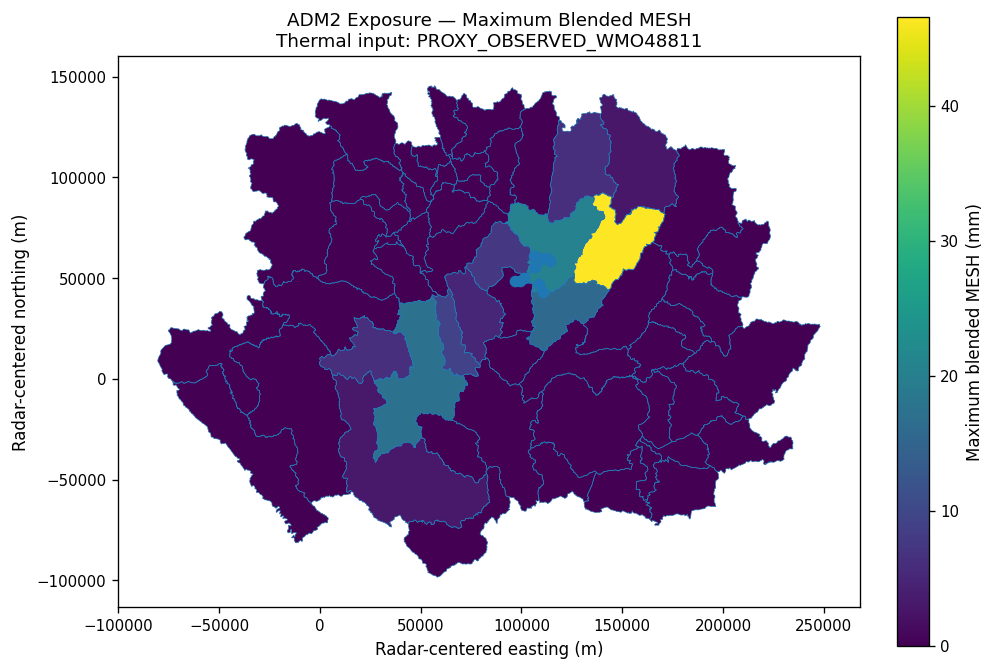

In [44]:
# CELL 44 — ADM2 maximum blended MESH map

plot_admin_exposure(
    ADM2_EXPOSURE_GDF,
    value_column=(
        "MESH_blend_max"
    ),
    coverage_column=(
        "MESH_blend_coverage"
    ),
    title=(
        "ADM2 Exposure — Maximum Blended MESH\n"
        f"Thermal input: {THERMAL_SOURCE_LABEL}"
    ),
    legend_label=(
        "Maximum blended MESH (mm)"
    ),
    output_path=(
        FIGURE_DIR
        / "10A_fig01_ADM2_max_MESH.png"
    ),
    admin_level="ADM2",
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/10A/10A_fig02_ADM2_MESH_ge40_area.png


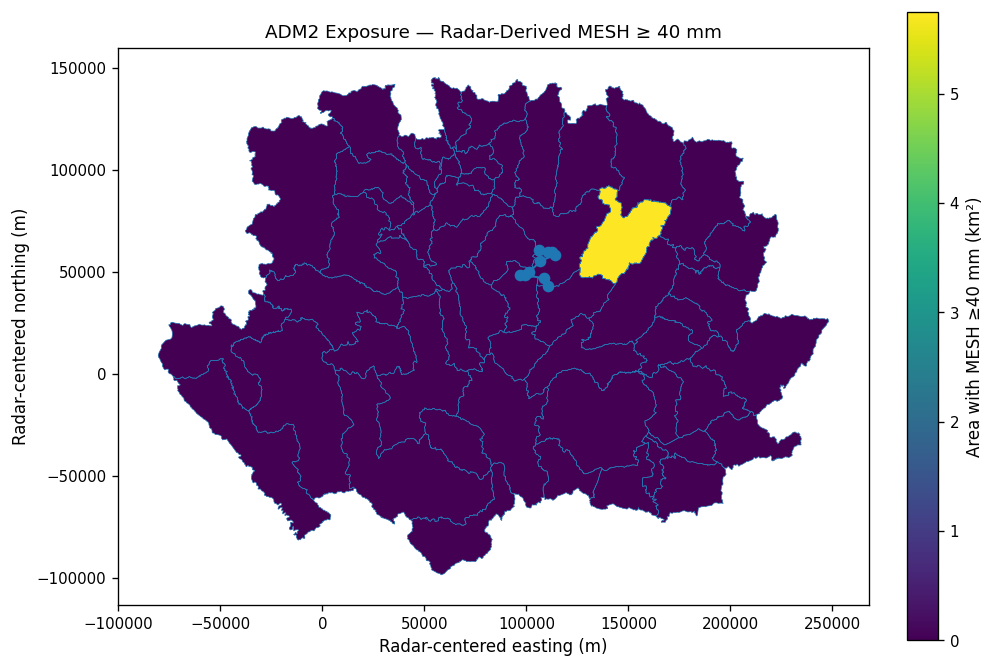

In [45]:
# CELL 45 — ADM2 area with MESH ≥40 mm

plot_admin_exposure(
    ADM2_EXPOSURE_GDF,
    value_column=(
        "MESH_blend_area_ge_40_km2"
    ),
    coverage_column=(
        "MESH_blend_coverage"
    ),
    title=(
        "ADM2 Exposure — Radar-Derived MESH ≥ 40 mm"
    ),
    legend_label=(
        "Area with MESH ≥40 mm (km²)"
    ),
    output_path=(
        FIGURE_DIR
        / "10A_fig02_ADM2_MESH_ge40_area.png"
    ),
    admin_level="ADM2",
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/10A/10A_fig03_ADM2_max_ET50.png


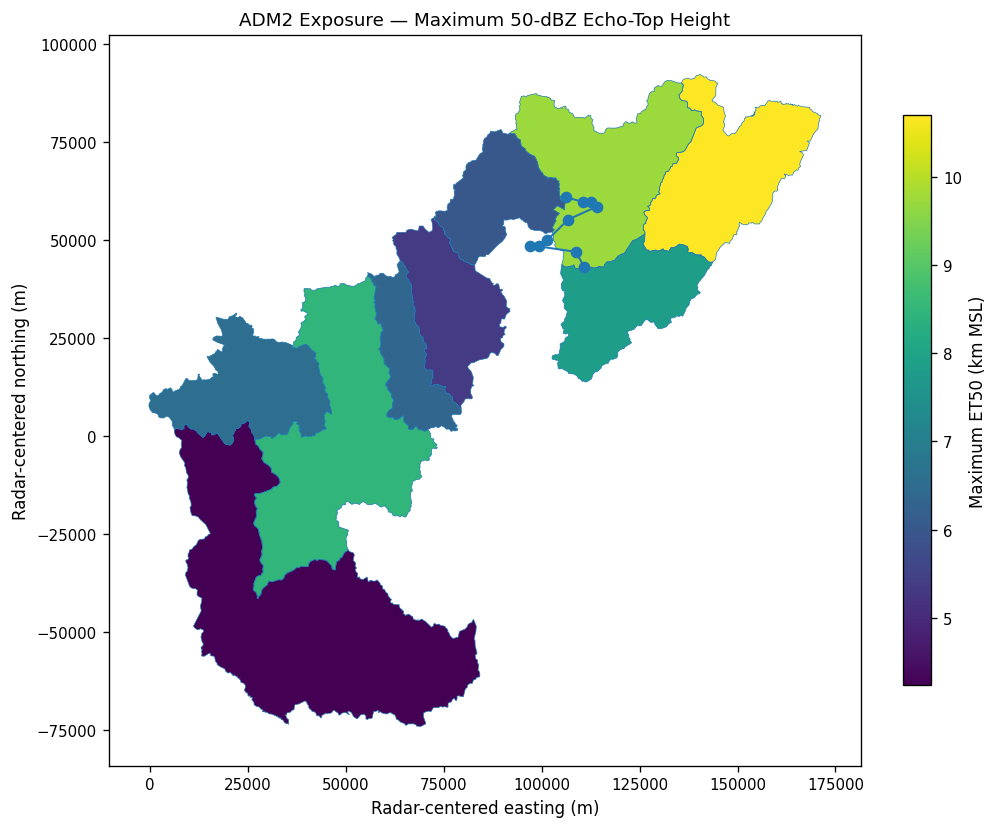

In [46]:
# CELL 46 — ADM2 maximum ET50 map

plot_admin_exposure(
    ADM2_EXPOSURE_GDF,
    value_column=(
        "ET50_max"
    ),
    coverage_column=(
        "ET50_coverage"
    ),
    title=(
        "ADM2 Exposure — Maximum 50-dBZ Echo-Top Height"
    ),
    legend_label=(
        "Maximum ET50 (km MSL)"
    ),
    output_path=(
        FIGURE_DIR
        / "10A_fig03_ADM2_max_ET50.png"
    ),
    admin_level="ADM2",
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/10A/10A_fig04_ADM2_max_VIL56.png


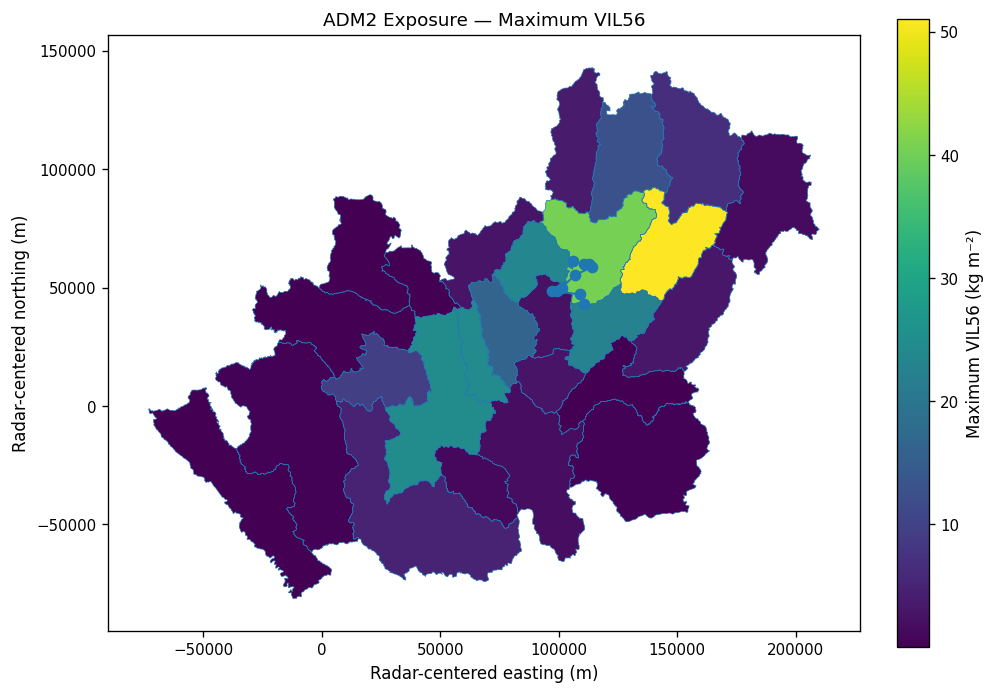

In [47]:
# CELL 47 — ADM2 maximum VIL56 map

plot_admin_exposure(
    ADM2_EXPOSURE_GDF,
    value_column=(
        "VIL56_max"
    ),
    coverage_column=(
        "VIL56_coverage"
    ),
    title=(
        "ADM2 Exposure — Maximum VIL56"
    ),
    legend_label=(
        "Maximum VIL56 (kg m⁻²)"
    ),
    output_path=(
        FIGURE_DIR
        / "10A_fig04_ADM2_max_VIL56.png"
    ),
    admin_level="ADM2",
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/10A/10A_fig05_ADM1_max_MESH.png


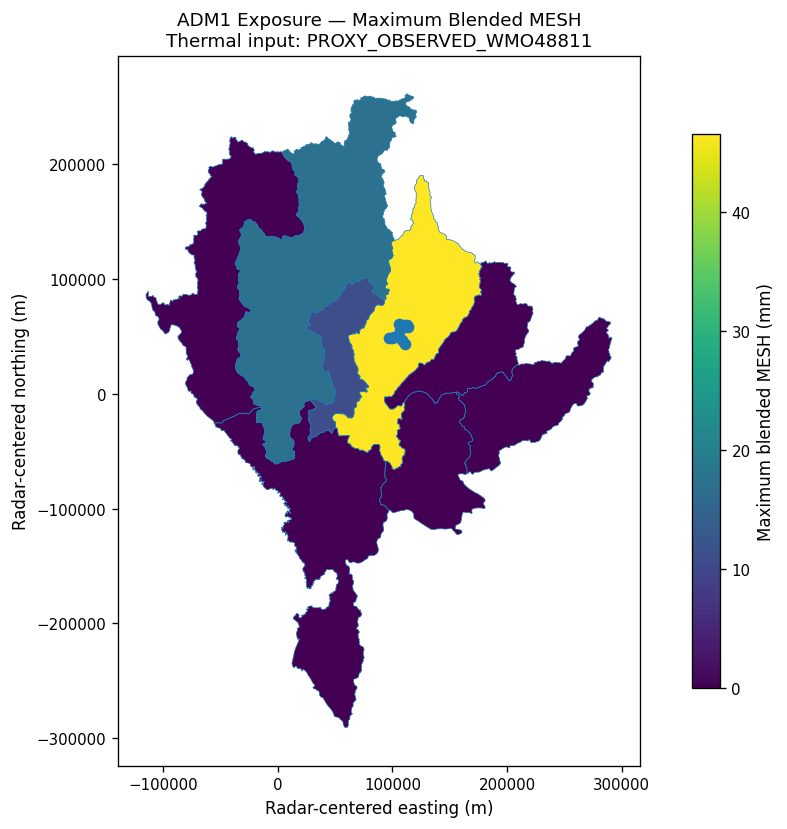

In [48]:
# CELL 48 — ADM1 maximum blended MESH map

plot_admin_exposure(
    ADM1_EXPOSURE_GDF,
    value_column=(
        "MESH_blend_max"
    ),
    coverage_column=(
        "MESH_blend_coverage"
    ),
    title=(
        "ADM1 Exposure — Maximum Blended MESH\n"
        f"Thermal input: {THERMAL_SOURCE_LABEL}"
    ),
    legend_label=(
        "Maximum blended MESH (mm)"
    ),
    output_path=(
        FIGURE_DIR
        / "10A_fig05_ADM1_max_MESH.png"
    ),
    admin_level="ADM1",
)

## Direct raster–administrative overlay

Choropleth map แสดงค่าที่สรุปแล้วใน polygon

Figure ต่อไปแสดง **original radar-derived MESH raster** พร้อม ADM2 boundaries โดยตรง เพื่อให้เห็นขั้นตอนก่อน zonal statistics:

```text
radar raster
+
polygon boundaries
+
storm-core track
```

การ overlay นี้ช่วย visualization แต่ยังไม่ใช่ physical validation

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/10A/10A_fig06a_MESH_raster_ADM2_overlay.png


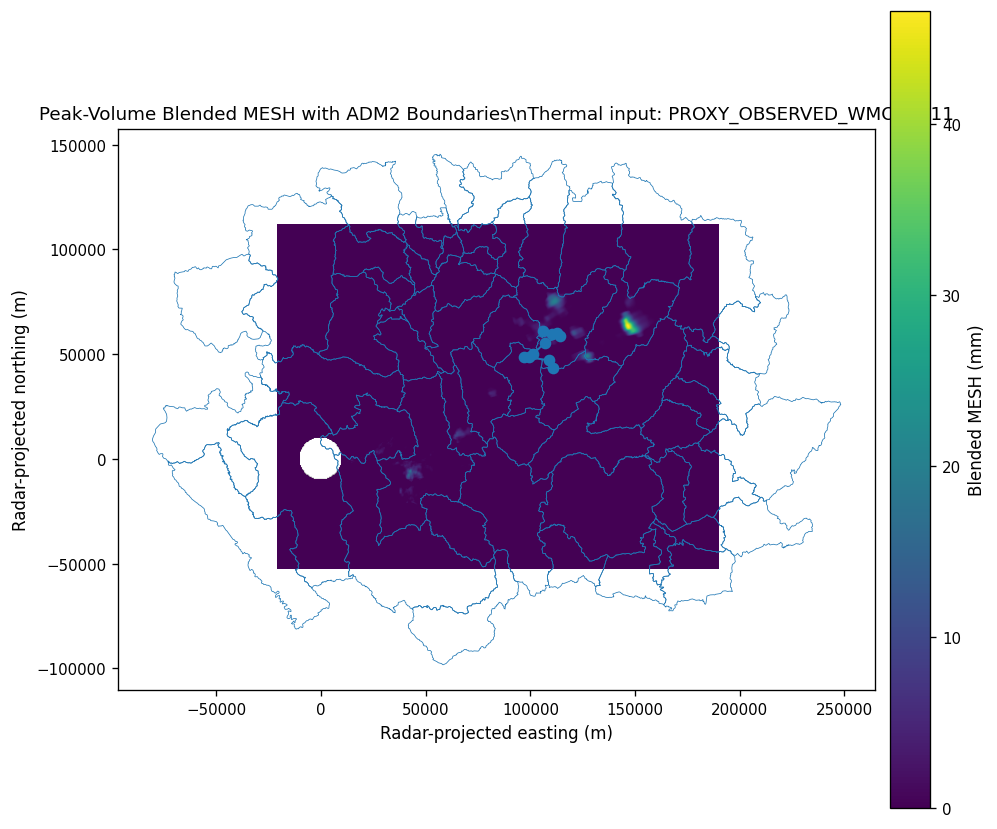

In [49]:
# CELL 48A — Direct MESH raster + ADM2 overlay

if "MESH_blend" in PRODUCT_PATHS:

    mesh_path = (
        PRODUCT_PATHS[
            "MESH_blend"
        ]
    )

    with rasterio.open(
        mesh_path
    ) as src:
        mesh_data = src.read(
            1,
            masked=True,
        )

        mesh_bounds = (
            src.bounds
        )

        mesh_extent = [
            mesh_bounds.left,
            mesh_bounds.right,
            mesh_bounds.bottom,
            mesh_bounds.top,
        ]

        mesh_crs = (
            src.crs
        )

    adm2_for_mesh = (
        ADM2_WORK.to_crs(
            mesh_crs
        )
    )

    fig = plt.figure(
        figsize=(
            8.2,
            6.8,
        )
    )

    ax = fig.add_subplot(
        111
    )

    image = ax.imshow(
        mesh_data,
        origin="upper",
        extent=(
            mesh_extent
        ),
        aspect="equal",
    )

    cbar = fig.colorbar(
        image,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        "Blended MESH (mm)"
    )

    local_adm2 = adm2_for_mesh.cx[
        mesh_bounds.left:
        mesh_bounds.right,
        mesh_bounds.bottom:
        mesh_bounds.top,
    ]

    local_adm2.boundary.plot(
        ax=ax,
        linewidth=0.45,
    )

    if not TRACK_LINE_RADAR.empty:
        TRACK_LINE_RADAR.to_crs(
            mesh_crs
        ).plot(
            ax=ax,
        )

    TRACK_POINTS_RADAR.to_crs(
        mesh_crs
    ).plot(
        ax=ax,
    )

    ax.set_xlabel(
        "Radar-projected easting (m)"
    )

    ax.set_ylabel(
        "Radar-projected northing (m)"
    )

    ax.set_title(
        "Peak-Volume Blended MESH with ADM2 Boundaries\\n"
        f"Thermal input: {THERMAL_SOURCE_LABEL}"
    )

    F = (
        FIGURE_DIR
        / "10A_fig06a_MESH_raster_ADM2_overlay.png"
    )

    save_figure(
        fig,
        F,
        product=(
            "MESH raster with ADM2 overlay"
        ),
        thermal_source=(
            THERMAL_SOURCE_LABEL
        ),
        interpretation=(
            "GIS overlay for spatial context; not hail validation."
        ),
    )

    plt.show()

# 32. Storm-core track map

Figure นี้แสดง:

```text
ADM2 boundaries
storm-core centroid points
centroid-to-centroid line
```

เวลาแต่ละจุดเป็น UTC

เส้น track เป็น visualization ระหว่าง discrete radar volumes  
ไม่ใช่ continuous observed storm trajectory

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/10A/10A_fig06_storm_core_track_ADM2.png


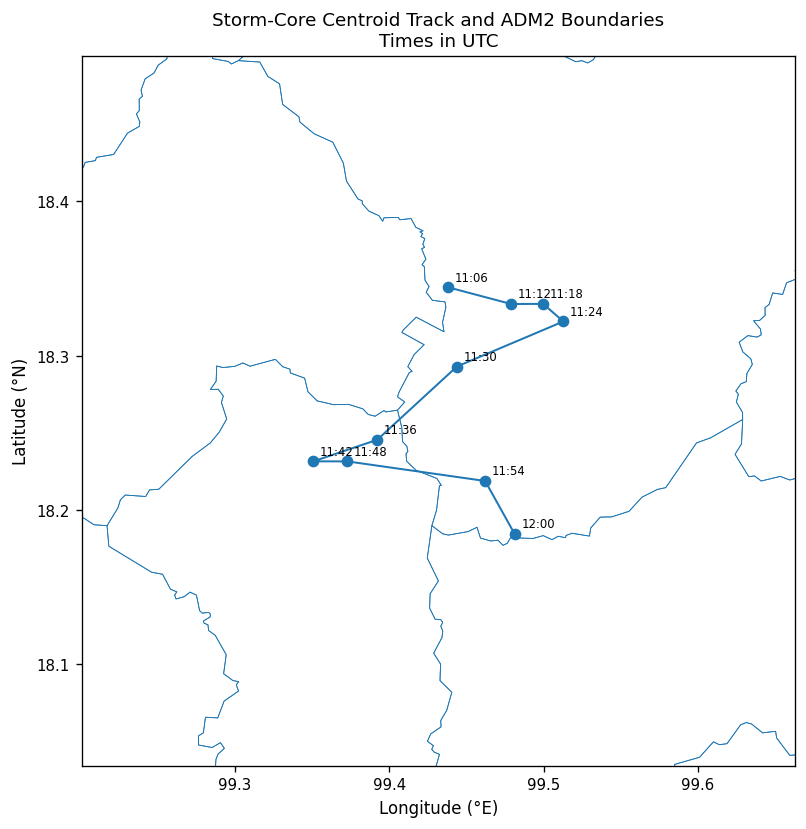

In [50]:
# CELL 49 — Geographic storm-core track map

ADM2_WGS84 = ADM2_WORK.to_crs(
    "EPSG:4326"
)

ADM1_WGS84 = ADM1_WORK.to_crs(
    "EPSG:4326"
)

TRACK_POINTS_WGS84 = (
    TRACK_POINTS_RADAR.to_crs(
        "EPSG:4326"
    )
)

TRACK_LINE_WGS84 = (
    TRACK_LINE_RADAR.to_crs(
        "EPSG:4326"
    )
    if not TRACK_LINE_RADAR.empty
    else TRACK_LINE_RADAR
)

if not TRACK_POINTS_WGS84.empty:

    track_bounds = (
        TRACK_POINTS_WGS84.total_bounds
    )

    longitude_margin = max(
        0.15,
        0.20
        * (
            track_bounds[
                2
            ]
            - track_bounds[
                0
            ]
        ),
    )

    latitude_margin = max(
        0.15,
        0.20
        * (
            track_bounds[
                3
            ]
            - track_bounds[
                1
            ]
        ),
    )

    local_adm2 = ADM2_WGS84.cx[
        track_bounds[
            0
        ]
        - longitude_margin:
        track_bounds[
            2
        ]
        + longitude_margin,
        track_bounds[
            1
        ]
        - latitude_margin:
        track_bounds[
            3
        ]
        + latitude_margin,
    ]

    fig = plt.figure(
        figsize=(
            8.0,
            6.8,
        )
    )

    ax = fig.add_subplot(
        111
    )

    local_adm2.boundary.plot(
        ax=ax,
        linewidth=0.5,
    )

    if not TRACK_LINE_WGS84.empty:
        TRACK_LINE_WGS84.plot(
            ax=ax,
        )

    TRACK_POINTS_WGS84.plot(
        ax=ax,
    )

    for _, row in (
        TRACK_POINTS_WGS84.iterrows()
    ):
        ax.annotate(
            row[
                "time_UTC"
            ].strftime(
                "%H:%M"
            ),
            (
                row.geometry.x,
                row.geometry.y,
            ),
            xytext=(
                4,
                4,
            ),
            textcoords="offset points",
            fontsize=7,
        )

    ax.set_xlim(
        track_bounds[
            0
        ]
        - longitude_margin,
        track_bounds[
            2
        ]
        + longitude_margin,
    )

    ax.set_ylim(
        track_bounds[
            1
        ]
        - latitude_margin,
        track_bounds[
            3
        ]
        + latitude_margin,
    )

    ax.set_xlabel(
        "Longitude (°E)"
    )

    ax.set_ylabel(
        "Latitude (°N)"
    )

    ax.set_title(
        "Storm-Core Centroid Track and ADM2 Boundaries\nTimes in UTC"
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    F = (
        FIGURE_DIR
        / "10A_fig06_storm_core_track_ADM2.png"
    )

    save_figure(
        fig,
        F,
        product=(
            "storm-core centroid track"
        ),
        admin_level="ADM2",
        interpretation=(
            "Centroid track; not storm boundary or observed hail path."
        ),
    )

    plt.show()

# 33. MESH pixel-rule sensitivity figure

เปรียบเทียบพื้นที่ MESH ≥40 mm จาก:

```text
pixel-center
vs
all-touched
```

จุดใกล้เส้น 1:1 หมายถึงผลไม่ไวต่อ inclusion rule มาก

แต่ sensitivity ที่น้อยไม่ได้แปลว่า MESH ได้รับ validation

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/10A/10A_fig07_MESH_pixel_rule_sensitivity.png


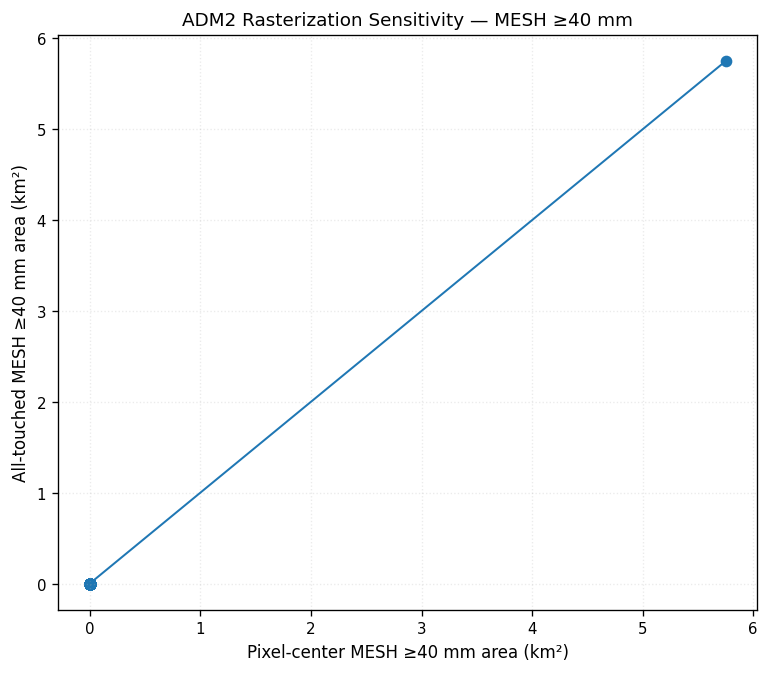

In [51]:
# CELL 50 — Pixel-center versus all-touched MESH area

if (
    not MESH_EDGE_SENSITIVITY.empty
    and "area_ge_40_km2_pixel_center"
    in MESH_EDGE_SENSITIVITY.columns
    and "area_ge_40_km2_all_touched"
    in MESH_EDGE_SENSITIVITY.columns
):
    plot_table = (
        MESH_EDGE_SENSITIVITY[
            [
                "area_ge_40_km2_pixel_center",
                "area_ge_40_km2_all_touched",
            ]
        ]
        .dropna()
    )

    fig = plt.figure(
        figsize=(
            6.3,
            5.5,
        )
    )

    ax = fig.add_subplot(
        111
    )

    ax.scatter(
        plot_table[
            "area_ge_40_km2_pixel_center"
        ],
        plot_table[
            "area_ge_40_km2_all_touched"
        ],
    )

    if not plot_table.empty:
        maximum_axis = max(
            float(
                plot_table.max().max()
            ),
            1.0,
        )

        ax.plot(
            [
                0.0,
                maximum_axis,
            ],
            [
                0.0,
                maximum_axis,
            ],
        )

    ax.set_xlabel(
        "Pixel-center MESH ≥40 mm area (km²)"
    )

    ax.set_ylabel(
        "All-touched MESH ≥40 mm area (km²)"
    )

    ax.set_title(
        "ADM2 Rasterization Sensitivity — MESH ≥40 mm"
    )

    ax.grid(
        alpha=0.25,
        linestyle=":",
    )

    F = (
        FIGURE_DIR
        / "10A_fig07_MESH_pixel_rule_sensitivity.png"
    )

    save_figure(
        fig,
        F,
        product=(
            "MESH pixel-rule sensitivity"
        ),
        units="km2",
    )

    plt.show()

# 34. Event-scale administrative exposure summary

Summary นี้ตอบเพียง:

```text
How many administrative units intersected selected radar-derived categories?
```

ใช้เฉพาะ units ที่มี valid radar support

ไม่ใช่จำนวนจังหวัด/อำเภอที่ได้รับความเสียหาย

In [52]:
# CELL 51 — Event exposure summary

summary_rows = []

for admin_level, wide_table in [
    (
        "ADM1",
        ADM1_EXPOSURE_INTEGRATED,
    ),
    (
        "ADM2",
        ADM2_EXPOSURE_INTEGRATED,
    ),
]:
    if (
        "MESH_blend_coverage"
        in wide_table.columns
    ):
        supported = wide_table.loc[
            wide_table[
                "MESH_blend_coverage"
            ]
            > 0.0
        ]

        for threshold in [
            20,
            40,
            50,
        ]:
            field = (
                f"MESH_blend_area_ge_{threshold}_km2"
            )

            if field in (
                supported.columns
            ):
                summary_rows.append({
                    "admin_level": (
                        admin_level
                    ),
                    "category": (
                        f"MESH ≥ {threshold} mm"
                    ),
                    "units_with_any_exceedance": int(
                        (
                            supported[
                                field
                            ]
                            > 0.0
                        ).sum()
                    ),
                    "total_exceedance_area_km2_sum_by_admin": float(
                        supported[
                            field
                        ].sum()
                    ),
                    "interpretation": (
                        "Radar-derived MESH category; not observed hail diameter."
                    ),
                })

    if (
        "ET50_coverage"
        in wide_table.columns
    ):
        supported = wide_table.loc[
            wide_table[
                "ET50_coverage"
            ]
            > 0.0
        ]

        for threshold in [
            8,
            10,
            12,
        ]:
            field = (
                f"ET50_area_ge_{threshold}_km2"
            )

            if field in (
                supported.columns
            ):
                summary_rows.append({
                    "admin_level": (
                        admin_level
                    ),
                    "category": (
                        f"ET50 ≥ {threshold} km MSL"
                    ),
                    "units_with_any_exceedance": int(
                        (
                            supported[
                                field
                            ]
                            > 0.0
                        ).sum()
                    ),
                    "total_exceedance_area_km2_sum_by_admin": float(
                        supported[
                            field
                        ].sum()
                    ),
                    "interpretation": (
                        "Teaching structural category; not a universal severe threshold."
                    ),
                })


EVENT_EXPOSURE_SUMMARY = pd.DataFrame(
    summary_rows
)

display(
    EVENT_EXPOSURE_SUMMARY
)

EVENT_EXPOSURE_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "10A_event_administrative_exposure_summary.csv"
)

EVENT_EXPOSURE_SUMMARY.to_csv(
    EVENT_EXPOSURE_SUMMARY_CSV,
    index=False,
)

,admin_level,category,units_with_any_exceedance,total_exceedance_area_km2_sum_by_admin,interpretation
0,ADM1,MESH ≥ 20 mm,1,37.50,Radar-derived MESH category; not observed hail...
1,ADM1,MESH ≥ 40 mm,1,5.75,Radar-derived MESH category; not observed hail...
2,ADM1,MESH ≥ 50 mm,0,0.00,Radar-derived MESH category; not observed hail...
3,ADM1,ET50 ≥ 8 km MSL,2,66.25,Teaching structural category; not a universal ...
4,ADM1,ET50 ≥ 10 km MSL,1,17.00,Teaching structural category; not a universal ...
5,ADM1,ET50 ≥ 12 km MSL,0,0.00,Teaching structural category; not a universal ...
6,ADM2,MESH ≥ 20 mm,2,37.50,Radar-derived MESH category; not observed hail...
7,ADM2,MESH ≥ 40 mm,1,5.75,Radar-derived MESH category; not observed hail...
8,ADM2,MESH ≥ 50 mm,0,0.00,Radar-derived MESH category; not observed hail...
9,ADM2,ET50 ≥ 8 km MSL,3,66.25,Teaching structural category; not a universal ...


# 35. Export GeoPackage

Notebook จะสร้าง:

```text
10A_administrative_exposure.gpkg
```

layers:

```text
adm1_exposure
adm2_exposure
storm_core_points
storm_core_track
```

Exposure polygons export เป็น EPSG:4326 เพื่อให้นำไปใช้ใน QGIS/ArcGIS ได้สะดวก

ค่าพื้นที่ยังคงเป็นค่าที่คำนวณใน projected radar CRS

In [53]:
# CELL 52 — Prepare GeoPackage layers

ADM1_EXPORT = ADM1_EXPOSURE_GDF.to_crs(
    "EPSG:4326"
)

ADM2_EXPORT = ADM2_EXPOSURE_GDF.to_crs(
    "EPSG:4326"
)

TRACK_POINTS_EXPORT = TRACK_POINTS_RADAR.to_crs(
    "EPSG:4326"
)

TRACK_LINE_EXPORT = (
    TRACK_LINE_RADAR.to_crs(
        "EPSG:4326"
    )
    if not TRACK_LINE_RADAR.empty
    else TRACK_LINE_RADAR.copy()
)

for frame in [
    ADM1_EXPORT,
    ADM2_EXPORT,
]:
    frame[
        "event_id"
    ] = str(
        ACTIVE_EVENT.get(
            "event_id"
        )
    )

    frame[
        "thermal_input_mode"
    ] = (
        THERMAL_INPUT_MODE
    )

    frame[
        "thermal_source"
    ] = (
        THERMAL_SOURCE_LABEL
    )


def make_datetime_fields_string(
    geodataframe,
):
    output = geodataframe.copy()

    for column in output.columns:
        if column == "geometry":
            continue

        if (
            pd.api.types.is_datetime64_any_dtype(
                output[
                    column
                ]
            )
        ):
            output[
                column
            ] = output[
                column
            ].astype(
                str
            )

    return output


ADM1_EXPORT = make_datetime_fields_string(
    ADM1_EXPORT
)

ADM2_EXPORT = make_datetime_fields_string(
    ADM2_EXPORT
)

TRACK_POINTS_EXPORT = make_datetime_fields_string(
    TRACK_POINTS_EXPORT
)

TRACK_LINE_EXPORT = make_datetime_fields_string(
    TRACK_LINE_EXPORT
)

In [54]:
# CELL 53 — Write GeoPackage

EXPOSURE_GPKG = (
    OUTPUT_GPKG_DIR
    / "10A_administrative_exposure.gpkg"
)

if EXPOSURE_GPKG.exists():
    EXPOSURE_GPKG.unlink()


ADM1_EXPORT.to_file(
    EXPOSURE_GPKG,
    layer="adm1_exposure",
    driver="GPKG",
    engine="pyogrio",
)

ADM2_EXPORT.to_file(
    EXPOSURE_GPKG,
    layer="adm2_exposure",
    driver="GPKG",
    engine="pyogrio",
    mode="a",
)

TRACK_POINTS_EXPORT.to_file(
    EXPOSURE_GPKG,
    layer="storm_core_points",
    driver="GPKG",
    engine="pyogrio",
    mode="a",
)

if not TRACK_LINE_EXPORT.empty:
    TRACK_LINE_EXPORT.to_file(
        EXPOSURE_GPKG,
        layer="storm_core_track",
        driver="GPKG",
        engine="pyogrio",
        mode="a",
    )

print(
    "Saved:",
    EXPOSURE_GPKG,
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/geopackage/10A_administrative_exposure.gpkg


In [55]:
# CELL 54 — Reopen GeoPackage and validate layers

GPKG_LAYERS = gpd.list_layers(
    EXPOSURE_GPKG
)

display(
    GPKG_LAYERS
)

expected_gpkg_layers = {
    "adm1_exposure",
    "adm2_exposure",
    "storm_core_points",
}

if not TRACK_LINE_EXPORT.empty:
    expected_gpkg_layers.add(
        "storm_core_track"
    )

actual_gpkg_layers = set(
    GPKG_LAYERS[
        "name"
    ].astype(
        str
    )
)

GPKG_LAYER_CHECK = (
    expected_gpkg_layers.issubset(
        actual_gpkg_layers
    )
)

print(
    "GeoPackage layer check:",
    (
        "PASS"
        if GPKG_LAYER_CHECK
        else "FAIL"
    ),
)

,name,geometry_type
0,adm1_exposure,MultiPolygon
1,adm2_exposure,MultiPolygon
2,storm_core_points,Point
3,storm_core_track,LineString


GeoPackage layer check: PASS


# 36. แนวทางเขียน Methods

Methods สำหรับ Notebook 10A ควรรายงานอย่างน้อย:

1. administrative boundary source และ version
2. ADM1 / ADM2 layer
3. boundary simplification status
4. radar raster CRS
5. raster pixel size
6. raster products ที่ใช้
7. zonal-statistics inclusion rule
8. NoData treatment
9. valid-radar coverage calculation
10. ranking coverage filter
11. reflectivity categories
12. ET50 teaching categories
13. MESH categories
14. MESH thermal-input provenance
15. pixel-center vs all-touched sensitivity
16. storm-core centroid source
17. coordinate transformation ของ track
18. administrative point/line intersection method
19. statement that exposure is not verified impact
20. statement that MESH is not observed hail diameter

ตัวอย่าง Methods:

> Peak radar-derived severe-storm and hail products were intersected with Thailand ADM1 and ADM2 administrative boundaries in the native radar-projected coordinate system. Zonal statistics were calculated using a pixel-center inclusion rule, with radar NoData excluded from all statistics. For each administrative polygon, valid radar coverage, mean, median, 90th and 95th percentiles, and maximum values were calculated. Product-specific exceedance areas were estimated from the projected raster pixel area. Administrative rankings were restricted to polygons with at least 50% valid radar coverage as a teaching screening criterion. For blended MESH, the sensitivity of exceedance area to the raster–polygon inclusion rule was evaluated by repeating ADM2 statistics using `all_touched=True`. Storm-core centroids from the radar lifecycle analysis were transformed to geographic coordinates and intersected with ADM1 and ADM2 polygons. All MESH-based results retained the environmental-input provenance from the remote observed sounding proxy used in the hail-retrieval workflow.

# 37. แนวทางเขียน Results

ควรจัดผลเป็น 4 ส่วน:

### Administrative radar support

- จำนวน ADM1/ADM2 ที่มี valid raster support
- coverage distribution

### Severe-storm exposure

- ET50 maximum / P95
- VIL maximum / P95
- reflectivity footprint

### Hail-related radar exposure

- MESH maximum
- MESH ≥20 / 40 / 50 mm areas
- explicit proxy-sounding limitation

### Storm-track exposure

- administrative units containing storm-core centroids
- approximate centroid-track length inside polygons

ไม่ควรใช้คำว่า:

```text
affected district
damaged district
hail-confirmed district
```

หากไม่มี independent impact/hail observation ในระดับพื้นที่

# 38. CORE — แบบฝึกหัดปริญญาตรี

### Exercise 1 — Radar support

จาก `10A_radar_support_by_admin_level.csv`

ตอบ:

- มี ADM1 กี่แห่งที่มี radar support?
- มี ADM2 กี่แห่งที่ coverage ≥50%?
- เหตุใด polygon ที่ coverage = 0 จึงไม่ควรถูกตีความว่าไม่มีพายุ?

### Exercise 2 — MESH exposure

จาก `10A_ADM2_MESH_ranking.csv`

เลือก 5 อำเภออันดับแรก แล้วรายงาน:

```text
maximum MESH
P95 MESH
area MESH ≥20 mm
area MESH ≥40 mm
coverage fraction
```

### Exercise 3 — ET50

เปรียบเทียบ top ADM2 จาก ET50 กับ top ADM2 จาก MESH

เหมือนกันหรือไม่?

### Exercise 4 — Storm track

จาก `10A_ADM2_storm_core_point_intersections.csv`

ตอบว่า storm-core centroid ผ่านเขตการปกครองใดตามลำดับเวลา

# 39. ADVANCED / MSc — แบบฝึกหัด

### Exercise 5 — Pixel-rule sensitivity

ใช้:

`10A_ADM2_MESH_pixel_rule_sensitivity.csv`

หาว่า ADM2 ใดมีความแตกต่างระหว่าง pixel-center และ all-touched สูงที่สุดสำหรับ MESH ≥40 mm

อภิปรายความสัมพันธ์กับ:

- polygon size
- polygon shape
- raster resolution

### Exercise 6 — Coverage filter

ทดลองเปลี่ยน:

```python
RANKING_MIN_COVERAGE_FRACTION = 0.50
```

เป็น:

```text
0.30
0.70
0.90
```

แล้วดู ranking เปลี่ยนอย่างไร

### Exercise 7 — Physical versus administrative footprint

เลือก ADM2 หนึ่งแห่งที่:

```text
MESH footprint > 0
แต่ core_point_count = 0
```

อธิบายว่าทำไมสองเงื่อนไขนี้เกิดพร้อมกันได้

### Exercise 8 — Research extension

ถ้ามี:

```text
population
cropland
road network
building footprints
damage reports
```

ออกแบบ exposure/impact analysis ต่อจาก GeoPackage ของ Notebook 10A

# 40. RESEARCH NOTE — ข้อจำกัด

Notebook 10A ยังไม่ได้ประเมิน:

- population exposure
- building exposure
- agricultural loss
- road disruption
- observed hail diameter by district
- hail duration at surface
- verified damage path
- local calibration of MESH
- uncertainty from full-resolution vs simplified ADM2 boundaries

ดังนั้นคำว่า **administrative exposure** ในบทนี้ต้องคงความหมายเชิง GIS overlay เท่านั้น

# 41. ทางต่อไป — Notebook 11A

Notebook 11A จะเปลี่ยน outputs ของ 09A–10A เป็น research mini-project:

```text
Research question
        ↓
Hypothesis
        ↓
Data provenance
        ↓
Radar / GIS methods
        ↓
Figures
        ↓
Tables
        ↓
Statistics
        ↓
Interpretation
        ↓
Limitations
        ↓
Reproducible research package
```

หัวข้อที่เหมาะ:

1. severe-storm lifecycle
2. MESH formulation / thermal sensitivity
3. administrative MESH exposure
4. ET50–VIL–MESH relationship
5. storm-track and GIS exposure

# 42. Export processing metadata

In [56]:
# CELL 55 — Processing metadata

track_length_km_value = (
    float(
        TRACK_LINE_GEOMETRY.length
        / 1000.0
    )
    if TRACK_LINE_GEOMETRY
    is not None
    else np.nan
)

metadata_rows = [
    (
        "event_id",
        ACTIVE_EVENT.get(
            "event_id"
        ),
    ),
    (
        "event_type",
        ACTIVE_EVENT.get(
            "event_type"
        ),
    ),
    (
        "analysis_track",
        "A",
    ),
    (
        "analysis_name",
        "GIS Exposure and Administrative Analysis",
    ),
    (
        "GIS_source_file",
        str(
            GIS_GPKG
        ),
    ),
    (
        "ADM1_feature_count",
        len(
            ADM1_WORK
        ),
    ),
    (
        "ADM2_feature_count",
        len(
            ADM2_WORK
        ),
    ),
    (
        "ADM1_name_source_field",
        ADM1_NAME_SOURCE,
    ),
    (
        "ADM2_name_source_field",
        ADM2_NAME_SOURCE,
    ),
    (
        "boundary_note",
        (
            "Course canonical administrative boundaries; "
            "ADM2 is simplified for teaching/visualization."
        ),
    ),
    (
        "reference_raster_product",
        REFERENCE_PRODUCT,
    ),
    (
        "reference_raster_CRS",
        str(
            REFERENCE_CRS
        ),
    ),
    (
        "reference_raster_width",
        REFERENCE_WIDTH,
    ),
    (
        "reference_raster_height",
        REFERENCE_HEIGHT,
    ),
    (
        "reference_pixel_area_km2",
        REFERENCE_PIXEL_AREA_KM2,
    ),
    (
        "products_analyzed",
        str(
            sorted(
                PRODUCT_SPECS_AVAILABLE.keys()
            )
        ),
    ),
    (
        "primary_all_touched",
        PRIMARY_ALL_TOUCHED,
    ),
    (
        "primary_pixel_rule",
        (
            "pixel-center"
            if not PRIMARY_ALL_TOUCHED
            else "all-touched"
        ),
    ),
    (
        "ranking_minimum_coverage_fraction",
        RANKING_MIN_COVERAGE_FRACTION,
    ),
    (
        "MESH_all_touched_sensitivity",
        MESH_SENSITIVITY_ALL_TOUCHED,
    ),
    (
        "thermal_input_mode",
        THERMAL_INPUT_MODE,
    ),
    (
        "thermal_source_label",
        THERMAL_SOURCE_LABEL,
    ),
    (
        "storm_core_x_field",
        CENTER_X_COLUMN,
    ),
    (
        "storm_core_y_field",
        CENTER_Y_COLUMN,
    ),
    (
        "storm_core_point_count",
        len(
            TRACK_POINTS_RADAR
        ),
    ),
    (
        "storm_track_length_km",
        track_length_km_value,
    ),
    (
        "GeoPackage_path",
        str(
            EXPOSURE_GPKG
        ),
    ),
    (
        "GeoPackage_layer_check",
        GPKG_LAYER_CHECK,
    ),
    (
        "QPE_included",
        False,
    ),
    (
        "population_exposure_included",
        False,
    ),
    (
        "damage_validation_included",
        False,
    ),
    (
        "local_hail_size_validation_included",
        False,
    ),
    (
        "interpretation",
        (
            "Administrative exposure represents GIS overlap with "
            "radar-derived storm and hail signatures. "
            "It is not verified impact or observed hail-size truth."
        ),
    ),
]

PROCESSING_METADATA_10A = pd.DataFrame(
    metadata_rows,
    columns=[
        "parameter",
        "value",
    ],
)

display(
    PROCESSING_METADATA_10A
)

PROCESSING_METADATA_10A_CSV = (
    OUTPUT_CSV_DIR
    / "10A_processing_metadata.csv"
)

PROCESSING_METADATA_10A.to_csv(
    PROCESSING_METADATA_10A_CSV,
    index=False,
)

,parameter,value
0,event_id,20230318_observed_hail_1106_1200
1,event_type,observed_hail
2,analysis_track,A
3,analysis_name,GIS Exposure and Administrative Analysis
4,GIS_source_file,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
5,ADM1_feature_count,77
6,ADM2_feature_count,928
7,ADM1_name_source_field,shapeName
8,ADM2_name_source_field,shapeName
9,boundary_note,Course canonical administrative boundaries; AD...


# 43. Export figure manifest

In [57]:
# CELL 56 — Figure manifest

FIGURE_MANIFEST_10A = pd.DataFrame(
    FIGURE_RECORDS
)

FIGURE_MANIFEST_10A_CSV = (
    OUTPUT_CSV_DIR
    / "10A_figure_manifest.csv"
)

FIGURE_MANIFEST_10A.to_csv(
    FIGURE_MANIFEST_10A_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST_10A
)

,figure_name,figure_path,product,admin_level,thermal_source,dpi,interpretation,units
0,10A_fig01_ADM2_max_MESH.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH_blend_max,ADM2,PROXY_OBSERVED_WMO48811,300,NaN,NaN
1,10A_fig02_ADM2_MESH_ge40_area.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH_blend_area_ge_40_km2,ADM2,PROXY_OBSERVED_WMO48811,300,NaN,NaN
2,10A_fig03_ADM2_max_ET50.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,ET50_max,ADM2,PROXY_OBSERVED_WMO48811,300,NaN,NaN
3,10A_fig04_ADM2_max_VIL56.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,VIL56_max,ADM2,PROXY_OBSERVED_WMO48811,300,NaN,NaN
4,10A_fig05_ADM1_max_MESH.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH_blend_max,ADM1,PROXY_OBSERVED_WMO48811,300,NaN,NaN
5,10A_fig06a_MESH_raster_ADM2_overlay.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH raster with ADM2 overlay,NaN,PROXY_OBSERVED_WMO48811,300,GIS overlay for spatial context; not hail vali...,NaN
6,10A_fig06_storm_core_track_ADM2.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,storm-core centroid track,ADM2,NaN,300,Centroid track; not storm boundary or observed...,NaN
7,10A_fig07_MESH_pixel_rule_sensitivity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,MESH pixel-rule sensitivity,NaN,NaN,300,NaN,km2


# 44. Output inventory

In [58]:
# CELL 57 — Output inventory

EXPECTED_OUTPUTS = [
    ADM1_ZONAL_LONG_CSV,
    ADM2_ZONAL_LONG_CSV,
    COVERAGE_SUMMARY_CSV,
    ADM1_EXPOSURE_WIDE_CSV,
    ADM2_EXPOSURE_WIDE_CSV,
    ADM1_MESH_RANKING_CSV,
    ADM2_MESH_RANKING_CSV,
    ADM2_ET50_RANKING_CSV,
    ADM2_VIL_RANKING_CSV,
    MESH_EDGE_SENSITIVITY_CSV,
    TRACK_POINTS_CSV,
    ADM1_TRACK_JOIN_CSV,
    ADM2_TRACK_JOIN_CSV,
    ADM1_TRACK_LENGTH_CSV,
    ADM2_TRACK_LENGTH_CSV,
    ADM1_INTEGRATED_EXPOSURE_CSV,
    ADM2_INTEGRATED_EXPOSURE_CSV,
    EVENT_EXPOSURE_SUMMARY_CSV,
    PROCESSING_METADATA_10A_CSV,
    FIGURE_MANIFEST_10A_CSV,
    EXPOSURE_GPKG,
]

OUTPUT_INVENTORY_10A = pd.DataFrame({
    "path": [
        str(
            path
        )
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
    "exists": [
        Path(
            path
        ).exists()
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
})

display(
    OUTPUT_INVENTORY_10A
)

,path,exists
0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
1,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
3,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
4,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
5,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
6,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
7,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
8,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
9,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True


# 45. Final readiness

Notebook 10A ผ่านเมื่อ:

```text
Notebook 09A readiness PASS
ADM1 / ADM2 loaded
peak radar products available
MESH available
primary zonal statistics completed
administrative exposure tables exported
storm-core track generated
GeoPackage layers validated
processing metadata exported
```

การมี radar-derived exposure ไม่ได้ทำให้พื้นที่นั้นเป็น verified impact area

In [59]:
# CELL 58 — Notebook 10A readiness

checks = []


def add_check(
    item,
    passed,
    note="",
):
    checks.append({
        "item": (
            item
        ),
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": (
            note
        ),
    })


add_check(
    "Notebook 09A readiness",
    bool(
        (
            readiness_09A[
                "status"
            ]
            == "PASS"
        ).all()
    ),
)

add_check(
    "ADM1 loaded",
    len(
        ADM1_WORK
    )
    > 0,
    f"{len(ADM1_WORK)} features",
)

add_check(
    "ADM2 loaded",
    len(
        ADM2_WORK
    )
    > 0,
    f"{len(ADM2_WORK)} features",
)

add_check(
    "Reference radar raster available",
    REFERENCE_RASTER.exists(),
    str(
        REFERENCE_RASTER
    ),
)

add_check(
    "MESH blend spatial product available",
    (
        "MESH_blend"
        in PRODUCT_PATHS
        and PRODUCT_PATHS[
            "MESH_blend"
        ].exists()
    ),
)

add_check(
    "ET50 spatial product available",
    (
        "ET50"
        in PRODUCT_PATHS
        and PRODUCT_PATHS[
            "ET50"
        ].exists()
    ),
)

add_check(
    "VIL56 spatial product available",
    (
        "VIL56"
        in PRODUCT_PATHS
        and PRODUCT_PATHS[
            "VIL56"
        ].exists()
    ),
)

add_check(
    "ADM1 zonal statistics completed",
    not ADM1_ZONAL_LONG.empty,
)

add_check(
    "ADM2 zonal statistics completed",
    not ADM2_ZONAL_LONG.empty,
)

add_check(
    "ADM1 exposure table exported",
    ADM1_INTEGRATED_EXPOSURE_CSV.exists(),
)

add_check(
    "ADM2 exposure table exported",
    ADM2_INTEGRATED_EXPOSURE_CSV.exists(),
)

add_check(
    "MESH pixel-rule sensitivity completed",
    (
        (
            not MESH_SENSITIVITY_ALL_TOUCHED
        )
        or (
            not MESH_EDGE_SENSITIVITY.empty
        )
    ),
)

add_check(
    "Storm-core track has at least 2 points",
    len(
        TRACK_POINTS_RADAR
    )
    >= 2,
    f"{len(TRACK_POINTS_RADAR)} points",
)

add_check(
    "Storm-core track line created",
    TRACK_LINE_GEOMETRY
    is not None,
)

add_check(
    "GeoPackage created",
    EXPOSURE_GPKG.exists(),
)

add_check(
    "GeoPackage layer validation",
    GPKG_LAYER_CHECK,
)

add_check(
    "Thermal provenance retained",
    (
        THERMAL_INPUT_MODE
        != "unknown"
        and THERMAL_SOURCE_LABEL
        != "unknown"
    ),
    (
        f"{THERMAL_INPUT_MODE} | "
        f"{THERMAL_SOURCE_LABEL}"
    ),
)

add_check(
    "Processing metadata exported",
    PROCESSING_METADATA_10A_CSV.exists(),
)

add_check(
    "Figure manifest exported",
    FIGURE_MANIFEST_10A_CSV.exists(),
)


READINESS_10A = pd.DataFrame(
    checks
)

display(
    READINESS_10A
)

NOTEBOOK_10A_READY = bool(
    (
        READINESS_10A[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_10A_CSV = (
    OUTPUT_CSV_DIR
    / "10A_readiness_check.csv"
)

READINESS_10A.to_csv(
    READINESS_10A_CSV,
    index=False,
)

print()

if NOTEBOOK_10A_READY:
    print(
        "NOTEBOOK 10A GIS EXPOSURE AND ADMINISTRATIVE ANALYSIS READY"
    )

    print(
        "Next step: Notebook 11A — Research Mini-Project and Publication Workflow"
    )

else:
    print(
        "NOTEBOOK 10A REQUIRES REVIEW"
    )

,item,status,note
0,Notebook 09A readiness,PASS,
1,ADM1 loaded,PASS,77 features
2,ADM2 loaded,PASS,928 features
3,Reference radar raster available,PASS,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
4,MESH blend spatial product available,PASS,
5,ET50 spatial product available,PASS,
6,VIL56 spatial product available,PASS,
7,ADM1 zonal statistics completed,PASS,
8,ADM2 zonal statistics completed,PASS,
9,ADM1 exposure table exported,PASS,



NOTEBOOK 10A GIS EXPOSURE AND ADMINISTRATIVE ANALYSIS READY
Next step: Notebook 11A — Research Mini-Project and Publication Workflow


# ข้อความสำคัญที่ต้องจำ

1. **Administrative exposure ≠ verified impact**
2. **MESH ≠ observed hail diameter**
3. MESH thermal provenance ต้องตามไปกับ GIS outputs
4. polygon ที่ไม่มี radar support ไม่ควรถูกตีความว่าไม่มีพายุ
5. raster NoData ไม่เท่ากับศูนย์
6. pixel-center และ all-touched ให้พื้นที่ต่างกันได้
7. boundary simplification มีผลต่อ zonal statistics
8. CRS ต้องตรงกันก่อน raster–polygon analysis
9. projected pixel area ใช้คำนวณ threshold area
10. coverage filter เป็น teaching screening criterion
11. MESH ≥40 mm area ไม่ใช่ observed 40-mm hail swath
12. ET50 ≥10 km เป็น structural category ไม่ใช่ universal Thailand severe threshold
13. VIL/VILD ใช้ descriptive statistics โดยไม่บังคับ imported hail threshold
14. core centroid ไม่ใช่ storm footprint
15. centroid track ไม่ใช่ observed hail path
16. line between radar scans เป็น temporal interpolation
17. storm-core point intersection และ raster footprint exposure เป็นคนละ representation
18. GIS overlay ไม่ใช่ physical validation
19. GeoPackage เก็บ exposure attributes เพื่อใช้ต่อในงานวิจัย
20. impact analysis ต้องมี independent population/infrastructure/damage data

# Expected outputs

```text
event-specific 03_output/csv/
├── 10A_ADM1_zonal_statistics_long.csv
├── 10A_ADM2_zonal_statistics_long.csv
├── 10A_radar_support_by_admin_level.csv
├── 10A_ADM1_exposure_wide.csv
├── 10A_ADM2_exposure_wide.csv
├── 10A_ADM1_MESH_ranking.csv
├── 10A_ADM2_MESH_ranking.csv
├── 10A_ADM2_ET50_ranking.csv
├── 10A_ADM2_VIL56_ranking.csv
├── 10A_ADM2_MESH_pixel_rule_sensitivity.csv
├── 10A_storm_core_track_points.csv
├── 10A_ADM1_storm_core_point_intersections.csv
├── 10A_ADM2_storm_core_point_intersections.csv
├── 10A_ADM1_storm_track_intersection_length.csv
├── 10A_ADM2_storm_track_intersection_length.csv
├── 10A_ADM1_integrated_exposure.csv
├── 10A_ADM2_integrated_exposure.csv
├── 10A_event_administrative_exposure_summary.csv
├── 10A_processing_metadata.csv
├── 10A_figure_manifest.csv
└── 10A_readiness_check.csv
```

```text
event-specific 03_output/geopackage/
└── 10A_administrative_exposure.gpkg
    ├── adm1_exposure
    ├── adm2_exposure
    ├── storm_core_points
    └── storm_core_track
```

```text
event-specific 04_figures/10A/
├── ADM2 maximum MESH
├── ADM2 MESH ≥40 mm area
├── ADM2 maximum ET50
├── ADM2 maximum VIL56
├── ADM1 maximum MESH
├── storm-core track + ADM2
└── MESH pixel-rule sensitivity
```

เมื่อผ่าน:

```text
NOTEBOOK 10A GIS EXPOSURE AND ADMINISTRATIVE ANALYSIS READY
```

จากนั้น:

```text
11A — Research Mini-Project and Publication Workflow
```